# scATrans without spliced/unspliced layers: differential expression + enrichment + plotting

This tutorial is for the **majority of scRNA-seq users who do not have RNA
velocity (spliced/unspliced) layers** — just an ordinary count matrix from
10x, Smart-seq, or any other protocol. Everything below uses
`scat.differential_expression(...)` instead of `scat.active_score(...)`, and
never touches a `spliced`/`unspliced`/`mature`/`nascent` layer. The exact
same code works unmodified on a plain count-matrix `.h5ad` with no velocity
layers at all.

For the velocity-aware `active_score` workflow on the same dataset, see the
sibling tutorial {doc}`t_ec_active_transcription`.

## Dataset

We use `EC.h5ad`: endothelial cells (EC) subset from a real mouse spinal
cord single-nucleus RNA-seq dataset, comparing **uninjured controls (UN, 3
replicates)** against **spinal cord injury (SCI, 3 replicates)**:

> Squair, J.W., Gautier, M., Kathe, C., et al. (2021). Confronting false
> discoveries in single-cell differential expression. *Nature
> Communications* 12, 5692. DOI:
> [10.1038/s41467-021-25960-2](https://doi.org/10.1038/s41467-021-25960-2).
> GEO: [GSE165003](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE165003).

See {doc}`../references` for the full citation list. This paper is itself
about pseudoreplication and false-discovery risk in single-cell DE — fitting
context for this tutorial, which reports real, sometimes non-significant
results below rather than a cherry-picked toy example (small-n designs like
this 3-vs-3 comparison commonly have limited genome-wide DE power; see
{doc}`../statistical_guidance`).

`differential_expression` and `active_score` share the same downstream
tooling — `filter_active_genes`, all `scat.pl.*` plots, and every enrichment
function — the only difference is that `differential_expression` skips the
unspliced-excess term entirely.

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.insert(0, "../../src")  # use the in-repo scatrans, not any installed copy

import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import scatrans as scat

print("scatrans:", scat.__file__)

scatrans: /home/lieber/scATrans-main/docs/tutorials/../../src/scatrans/__init__.py


## Load and inspect

We deliberately only ever look at `adata.X` (raw counts) below — no
`layers` access anywhere in this notebook.

In [3]:
adata = sc.read_h5ad("../../EC.h5ad")
adata

AnnData object with n_obs × n_vars = 177 × 26451
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'condition', 'sample', 'GSM_ID', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors', 'scrublet'
    layers: 'ambiguous', 'mature', 'nascent', 'spliced', 'unspliced'

In [4]:
adata.obs[["condition", "sample", "GSM_ID"]].value_counts().sort_index()

condition  sample  GSM_ID    
SCI        rep1    GSM5024314    35
           rep2    GSM5024315    23
           rep3    GSM5024316    37
UN         rep1    GSM5024317    27
           rep2    GSM5024318    38
           rep3    GSM5024319    17
Name: count, dtype: int64

## QC and light filtering

This EC subset was already QC'd upstream (doublet scores, mito %, and gene
counts are precomputed in `.obs`). We apply the same filters here for
completeness / robustness — on this dataset they happen to remove zero
cells, since the upstream authors already excluded low-quality cells.

In [5]:
n0 = adata.n_obs
adata = adata[~adata.obs["predicted_doublet"]].copy()
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
adata = adata[adata.obs["n_genes_by_counts"] > 200].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"cells kept: {adata.n_obs} of {n0}")
print(f"genes kept: {adata.n_vars}")

cells kept: 177 of 177
genes kept: 9221


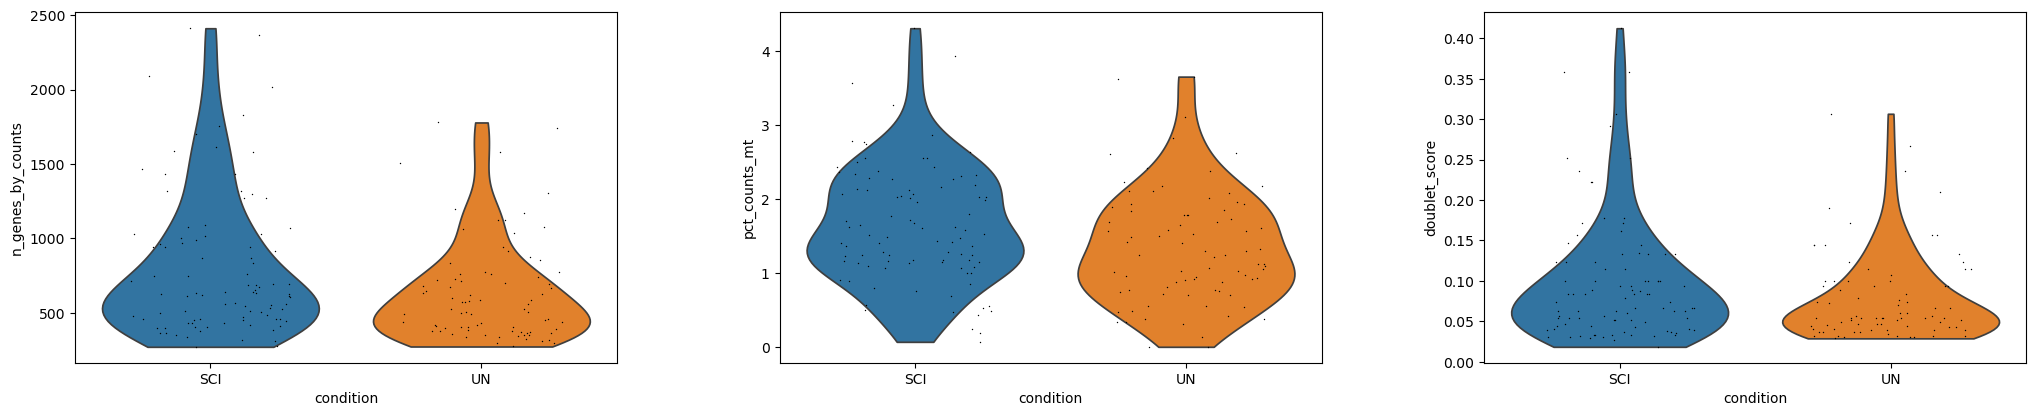

In [6]:
sc.pl.violin(
    adata, ["n_genes_by_counts", "pct_counts_mt", "doublet_score"],
    groupby="condition", jitter=0.3, multi_panel=True,
)

## Preserve raw counts, then preprocess

`store_raw_counts` snapshots `.X` into `layers["counts"]` (and `.raw`) before
any HVG/normalize/log1p step — this is what lets enrichment functions later
auto-supply the correct measured-gene background via `adata=`. Count-based
DE backends (PyDESeq2, Memento) need these raw integer counts; the
`de_preprocess="auto"` step inside `differential_expression` also uses the
`.uns["log1p"]` marker scanpy sets to detect whether `.X` is already
log-normalized (see {doc}`../user_guide/standalone_de` for the
`anndata.concat()` caveat around this marker).

In [7]:
scat.store_raw_counts(adata, layer="counts", save_raw=True)

adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

## Backend A: single-cell Wilcoxon DE

The simplest, fastest path: scanpy's `rank_genes_groups` directly on
log-normalized single cells.

In [8]:
adata_norm, de_wilcoxon = scat.differential_expression(
    adata_norm,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    de_method="wilcoxon",
    de_preprocess="none",  # we already normalized + log1p'd above
)
de_wilcoxon.sort_values("logFC", ascending=False).head(10)

,logFC,p_val,p_adj,baseMean
Tpcn1,27.242462,0.227766,0.9938,0.116235
Prdm16,27.127773,0.334591,0.9938,0.118895
Pgls,27.004536,0.227766,0.9938,0.126359
Nxn,27.004536,0.227766,0.9938,0.137124
Gm57952,27.004536,0.227766,0.9938,0.124299
Rab11fip1,27.004536,0.277691,0.9938,0.103826
Dmtf1,27.004536,0.147796,0.9938,0.125101
Pacsin2,26.871260,0.334591,0.9938,0.104579
Kcnj10,26.871260,0.227766,0.9938,0.122506
Plcl1,26.871260,0.277691,0.9938,0.112288


In [9]:
print("min p_adj:", de_wilcoxon["p_adj"].min())
print("genes with p_adj < 0.05:", (de_wilcoxon["p_adj"] < 0.05).sum())

min p_adj: 0.9938003852887332
genes with p_adj < 0.05: 0


:::{note}
With only 3 replicates per condition, **no gene reaches genome-wide
`p_adj < 0.05`** here — this is real, honest small-n biology, not a bug.
`filter_active_genes` with strict cutoffs legitimately returns very few or
zero candidates. The practical workaround (used throughout this notebook)
is to rank by nominal (unadjusted) p-value and effect size for
**hypothesis-generating** candidate lists, and to say so explicitly rather
than reporting `p_adj < 0.05` claims that the data does not support. See
{doc}`../statistical_guidance` for the full reporting checklist.
:::

In [10]:
candidates_strict = scat.filter_active_genes(de_wilcoxon, pval_cutoff=0.2, logfc_cutoff=0.3)
print("strict candidates (p_adj<0.2, |logFC|>0.3):", len(candidates_strict))

# Exploratory ranking: top 100 upregulated genes by nominal p-value
candidates = de_wilcoxon[de_wilcoxon["logFC"] > 0].sort_values("p_val").head(100)
print("exploratory candidates (top 100 upregulated by nominal p-value):", len(candidates))
candidates.head(10)

strict candidates (p_adj<0.2, |logFC|>0.3): 0
exploratory candidates (top 100 upregulated by nominal p-value): 100


,logFC,p_val,p_adj,baseMean
Rpl37,2.161662,0.000302,0.9938,1.468993
Spock2,2.577669,0.000312,0.9938,1.783297
Rpl35,2.087135,0.000397,0.9938,1.085354
Igf1r,1.444869,0.000446,0.9938,1.513025
Gpcpd1,1.772408,0.000603,0.9938,1.247660
Rpl37a,2.572021,0.001323,0.9938,1.647515
Rpl38,2.344653,0.001573,0.9938,1.909690
Gm68844,2.785950,0.001696,0.9938,1.732615
Rps19,1.891919,0.002009,0.9938,1.650908
Cpe,2.122542,0.002111,0.9938,0.719209


## Backend B: pseudobulk + PyDESeq2

With 3 biological replicates per group, aggregating to pseudobulk and
running count-based DESeq2 is the more defensible choice for a real
publication (see the DE-backend decision guide in
{doc}`../user_guide/workflow`). We compare its top genes against the
Wilcoxon single-cell result above — backend choice visibly changes which
genes come out on top.

In [11]:
adata_pb = adata.copy()
adata_pb, de_pseudobulk = scat.differential_expression(
    adata_pb,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    use_pseudobulk=True,
    sample_col="sample",
    pseudobulk_de_backend="pydeseq2",
)
print("min p_adj (pseudobulk):", de_pseudobulk["p_adj"].min())
de_pseudobulk.sort_values("logFC", ascending=False).head(10)

min p_adj (pseudobulk): 0.5584481513291821


,logFC,p_val,p_adj,baseMean
Prdm16,4.416334,0.043152,0.999513,2.833333
Jmy,4.315898,0.050361,0.999513,3.000000
Gm3764,4.147823,0.062356,0.999513,2.666667
Col4a3,3.979546,0.080037,0.999513,2.500000
Cd38,3.958031,0.080950,0.999513,2.000000
Fau,3.825012,0.093960,0.999513,2.000000
Gm57952,3.819496,0.096126,0.999513,2.000000
Itih3,3.744748,0.113096,0.999513,1.833333
Gkn3,3.726783,0.114265,0.999513,2.166667
Msantd4,3.667388,0.114968,0.999513,1.666667


In [12]:
top_wilcoxon = set(de_wilcoxon.sort_values("logFC", ascending=False).head(20).index)
top_pseudobulk = set(de_pseudobulk.sort_values("logFC", ascending=False).head(20).index)
print(f"overlap of top-20 genes (Wilcoxon vs. pseudobulk PyDESeq2): {len(top_wilcoxon & top_pseudobulk)} / 20")

overlap of top-20 genes (Wilcoxon vs. pseudobulk PyDESeq2): 7 / 20


## Backend C: Memento (method-of-moments cell-level DE)

[Memento](https://doi.org/10.1016/j.cell.2024.09.044) (*Cell*, 2024) is a
method-of-moments estimator that works directly on raw single-cell counts
(no pseudobulk aggregation, no log-normalization). It needs `use_memento_de=True`
and raw integer counts, which is exactly why we called `store_raw_counts`
above.

In [13]:
adata_mem = adata.copy()
adata_mem, de_memento = scat.differential_expression(
    adata_mem,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    use_memento_de=True,
)
de_memento.sort_values("logFC", ascending=False).head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 476 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 1476 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 2083 out of 2083 | elapsed:    7.5s finished


,logFC,p_val,p_adj,memento_de_se,memento_dv_coef,memento_dv_se,memento_dv_pval,baseMean
Gfap,2.883938,0.065733,0.987457,0.899865,1.124937,2.501670,0.873866,0.401130
Slc6a20a,2.396857,0.011514,0.666649,0.602903,1.624803,1.066352,0.204310,0.225989
Lama4,2.044974,0.030588,0.810178,0.590835,0.891034,1.457454,0.750794,0.175141
Mecom,1.958642,0.008734,0.606432,0.492907,1.074449,1.579175,0.649023,0.288136
Ptp4a2,1.812726,0.025814,0.810178,0.518275,1.446629,1.680044,0.983735,0.197740
Mcf2l,1.801148,0.086967,0.989809,0.644036,-0.380125,1.863114,0.596109,0.276836
Phf20l1,1.773532,0.224842,0.989809,0.801671,-2.442645,1.840142,0.092357,0.158192
Sar1b,1.726292,0.026552,0.810178,0.518877,1.886126,1.580312,0.884016,0.152542
Ifnar1,1.685207,0.035636,0.839459,0.518997,1.173949,1.289252,0.419856,0.225989
Taok1,1.676860,0.136702,0.989809,0.678254,-0.386383,2.072747,0.504406,0.163842


Three backends, three slightly different answers — this is exactly
the kind of pseudoreplication-sensitivity that the Squair et al. (2021)
paper behind this dataset warns about. Always report which backend was
used, per {doc}`../statistical_guidance`.

## Functional enrichment: the full tour

We use the 100-gene exploratory candidate list from Backend A for the ORA
methods below (`run_enrichment`, `run_kegg`, `run_go`), and the full ranked
`logFC` list for `run_gsea`.

In [14]:
candidate_genes = candidates.index.tolist()
down_genes = de_wilcoxon[de_wilcoxon["logFC"] < 0].sort_values("p_val").head(100).index.tolist()
len(candidate_genes), len(down_genes)

(100, 100)

### Over-representation analysis (ORA): GO Biological Process

In [15]:
go_res = scat.run_enrichment(
    candidate_genes,
    gene_sets="GO_Biological_Process",
    organism="mouse",
    adata=adata_norm,   # auto-supplies the stored measured-gene background
    return_all=True,
)
print(f"{len(go_res)} GO BP terms tested, {(go_res['p.adjust'] < 0.05).sum()} significant at p.adjust<0.05")
go_res.sort_values("pvalue").head(10)[["Term", "Count", "GeneRatio", "pvalue", "p.adjust"]]

6744 GO BP terms tested, 47 significant at p.adjust<0.05


,Term,Count,GeneRatio,pvalue,p.adjust
0,cytoplasmic translation (GO:0002181),23,0.237113,3.700163e-17,2.495390e-13
1,negative regulation of myoblast fusion (GO:190...,13,0.134021,1.380523e-15,4.655122e-12
2,negative regulation of syncytium formation by ...,13,0.134021,2.655028e-15,5.968503e-12
3,regulation of myoblast fusion (GO:1901739),13,0.134021,1.184686e-14,1.997380e-11
4,translation at synapse (GO:0140241),12,0.123711,7.259096e-14,7.073882e-11
6,translation at postsynapse (GO:0140242),12,0.123711,7.259096e-14,7.073882e-11
5,regulation of syncytium formation by plasma me...,13,0.134021,7.342405e-14,7.073882e-11
7,myoblast fusion (GO:0007520),13,0.134021,1.860772e-13,1.568630e-10
8,cell-cell fusion (GO:0140253),13,0.134021,1.443489e-12,9.734891e-10
9,syncytium formation by plasma membrane fusion ...,13,0.134021,1.443489e-12,9.734891e-10


Several ribosomal-protein genes (`Rpl37`, `Rpl35`, `Rpl37a`, `Rpl38`,
`Rps19`, ...) are in the candidate list, so "cytoplasmic translation" comes
out as the top term — unlike the per-gene DE p-values, gene-set-level ORA
here has genuine, well-powered signal.

### KEGG pathways

In [16]:
kegg_res = scat.run_kegg(
    candidate_genes,
    organism="mouse",
    adata=adata_norm,
    return_all=True,
)
kegg_res.sort_values("pvalue").head(10)[["Term", "Count", "pvalue", "p.adjust"]]

,Term,Count,pvalue,p.adjust
0,Ribosome(mmu03010),21,4.654655e-18,9.402402e-16
2,Parkinson disease(mmu05012),7,9.762118e-03,6.892085e-01
1,Oxidative phosphorylation(mmu00190),7,1.023577e-02,6.892085e-01
193,Alzheimer disease(mmu05010),7,2.363543e-02,1.000000e+00
32,Bile secretion(mmu04976),3,2.908569e-02,1.000000e+00
201,ABC transporters(mmu02010),2,5.766020e-02,1.000000e+00
66,Focal adhesion(mmu04510),6,6.453936e-02,1.000000e+00
38,Cardiac muscle contraction(mmu04260),3,7.023010e-02,1.000000e+00
72,Glioma(mmu05214),3,7.808674e-02,1.000000e+00
169,Small cell lung cancer(mmu05222),3,9.056147e-02,1.000000e+00


"Ribosome" is overwhelmingly the top KEGG hit here (`p.adjust` ≈ 1e-15) —
consistent with the GO result above.

### GO, all three ontologies at once (`ontology="ALL"`)

In [17]:
go_all = scat.run_go(
    candidate_genes,
    ontology="ALL",
    organism="mouse",
    adata=adata_norm,
    return_all=True,
    adjust_across_all=True,  # single BH correction across BP+CC+MF combined
)
print("ontologies covered:", list(go_all.attrs["per_ontology_attrs"].keys()))
go_all.sort_values("pvalue").head(6)[["Term", "Count", "pvalue", "p.adjust"]]

ontologies covered: ['BP', 'CC', 'MF']


,Term,Count,pvalue,p.adjust
0,cytoplasmic translation (GO:0002181),23,3.700163e-17,2.495390e-13
1,negative regulation of myoblast fusion (GO:190...,13,1.380523e-15,4.655122e-12
2,negative regulation of syncytium formation by ...,13,2.655028e-15,5.968503e-12
3,regulation of myoblast fusion (GO:1901739),13,1.184686e-14,1.997380e-11
6,translation at postsynapse (GO:0140242),12,7.259096e-14,7.073882e-11
5,translation at synapse (GO:0140241),12,7.259096e-14,7.073882e-11


### Pre-ranked GSEA

`run_gsea` takes a full ranked gene list (here, `logFC` from the Wilcoxon
DE result) rather than a fixed candidate cutoff — every gene contributes,
weighted by its rank.

:::{note}
`nperm` controls the permutation-based null distribution; we use a modest
`nperm=100` here to keep this tutorial cell fast (real run: ~27s). For a
manuscript, prefer a larger `nperm` (≥1000). Roughly 88% of genes in this
ranked list share tied `logFC` values (a side effect of the small-n design
above), which `run_gsea` warns about — tie-breaking within those ranks is
arbitrary, so treat exact `NES` values here as illustrative rather than
final.
:::

In [18]:
ranked = de_wilcoxon["logFC"].sort_values(ascending=False)
gsea_res = scat.run_gsea(
    ranked_genes=ranked,
    gene_sets="GO_Biological_Process",
    organism="mouse",
    nperm=100,
    min_size=15,
)
gsea_res.sort_values("p.adjust")[["Term", "NES", "pvalue", "p.adjust", "leading_edge"]].head(10)

2026-07-05 11:40:29,063 [WARNING] Duplicated values found in preranked stats: 87.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,pvalue,p.adjust,leading_edge
0,urogenital system development (GO:0001655),-2.180388,0.0,0.079007,Igf1;Acd;Osr1;Sulf1;Serpinf1;Acvr1
3,cerebral cortex radially oriented cell migrati...,-2.063498,0.0,0.102709,Bmerb1;Lamb1;Dcx;Fbxo45;Reln;Col3a1
4,regulation of fibroblast growth factor recepto...,-2.013076,0.0,0.116930,Smoc2;Runx2;Sulf1;Wnt4
2,diterpenoid metabolic process (GO:0016101),-2.074478,0.0,0.121144,Prmt3;Dgat1;Aldh1a1;Rbp4;Dhrs4;Cyp1b1
5,telencephalon glial cell migration (GO:0022030),-1.977310,0.0,0.137698,Bmerb1;Lamb1;Dcx;Reln;Col3a1
6,cerebral cortex radial glia-guided migration (...,-1.977310,0.0,0.137698,Bmerb1;Lamb1;Dcx;Reln;Col3a1
1,fibroblast growth factor receptor signaling pa...,-2.077310,0.0,0.181716,Sos1;Smoc2;Runx2;Sulf1;Wnt4;Fgfr2;Fgf9;Ccn2;Fg...
9,negative regulation of reproductive process (G...,-1.914572,0.0,0.205418,Igf1;Shb;Sulf1;Ptgds;Serpinf1;Wnt4
8,negative regulation of release of cytochrome c...,-1.915757,0.0,0.228242,Igf1
14,chondrocyte development (GO:0002063),-1.863570,0.0,0.243341,Runx2;Sulf1


:::{note}
Both `scat.pl.gseaplot(...)` (the running-sum plot) and `scat.pl.enrich_dotplot(gsea_res, x="NES", ...)` are shown below. An earlier draft of this tutorial found these calls effectively hung (>1 minute, no error) on a real, thousands-of-terms GSEA result. The root cause turned out to be a real scATrans performance bug, since fixed: `run_gsea` stored gseapy's full per-term running-enrichment-score curves in `gsea_res.attrs["gsea_details"]`, and pandas deep-copies `.attrs` on essentially every `DataFrame` operation (`.head()`, `.copy()`, slicing) via `NDFrame.__finalize__` — for a genome-wide ranked list against thousands of gene sets that is tens of millions of floats being deep-copied on every such call. See `CHANGELOG.md` for the fix (the payload is now wrapped so its `__deepcopy__` is an O(1) identity return).
:::

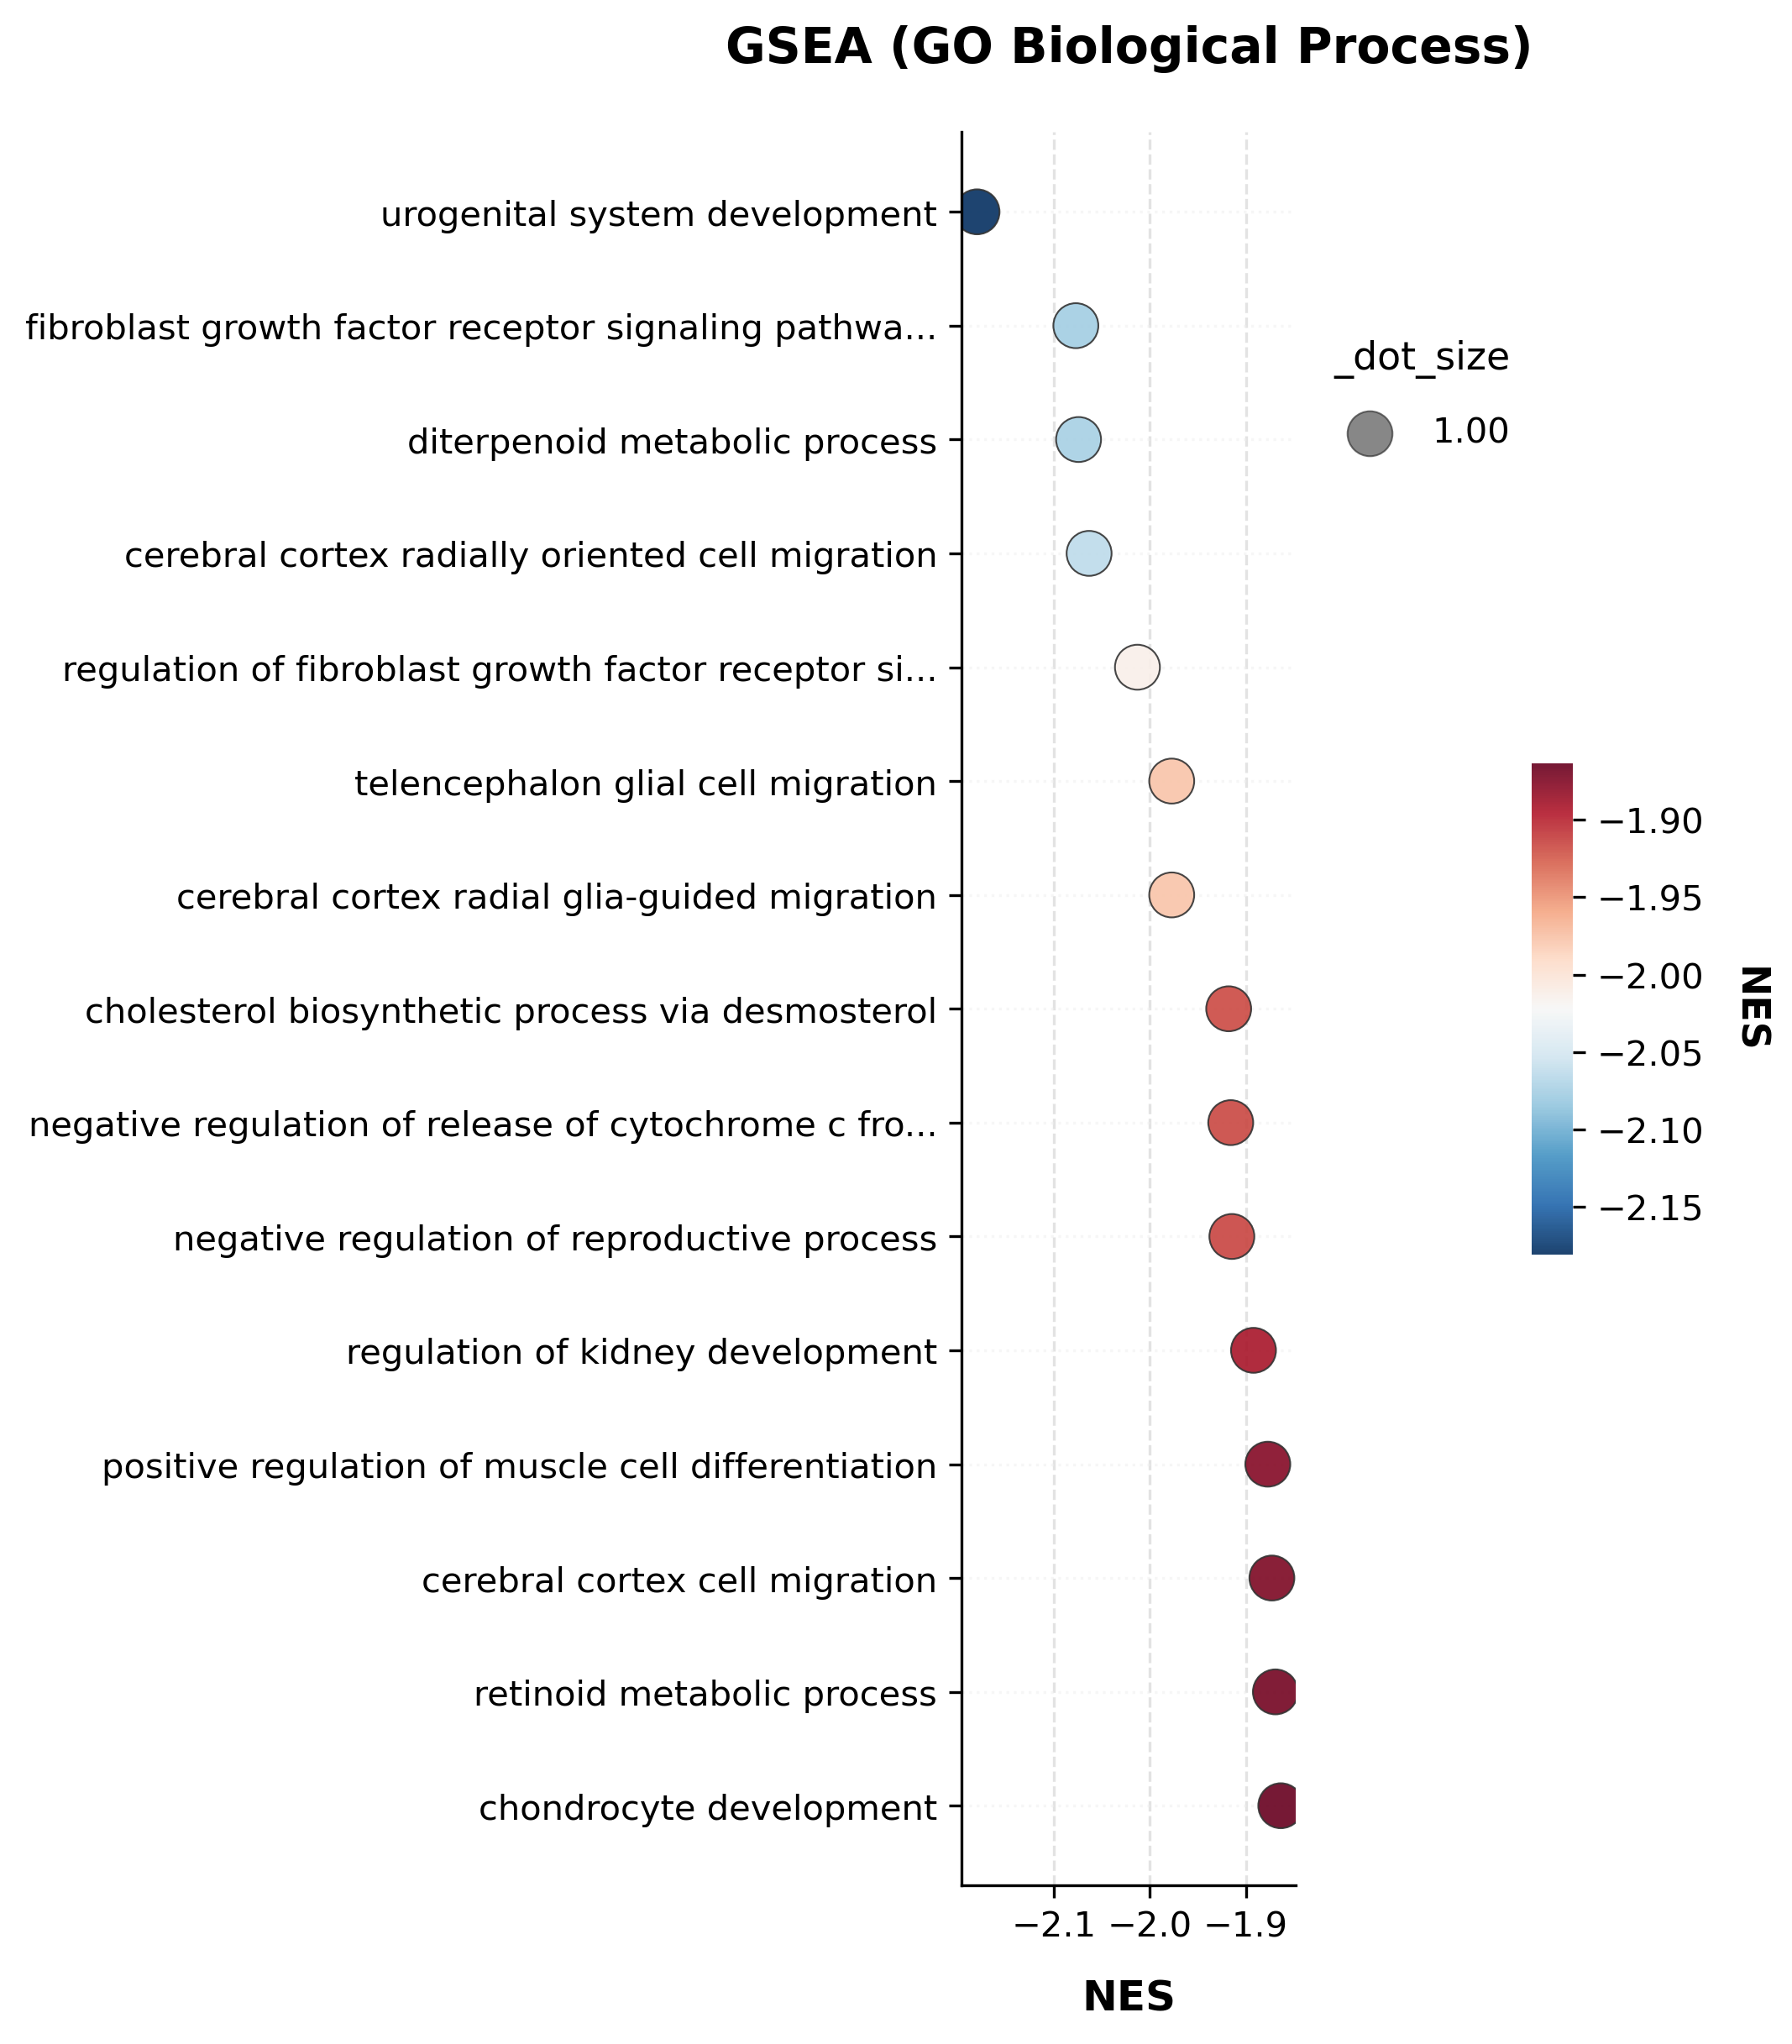

In [19]:
scat.pl.enrich_dotplot(gsea_res, top_n=15, x="NES", color_by="NES", title="GSEA (GO Biological Process)");

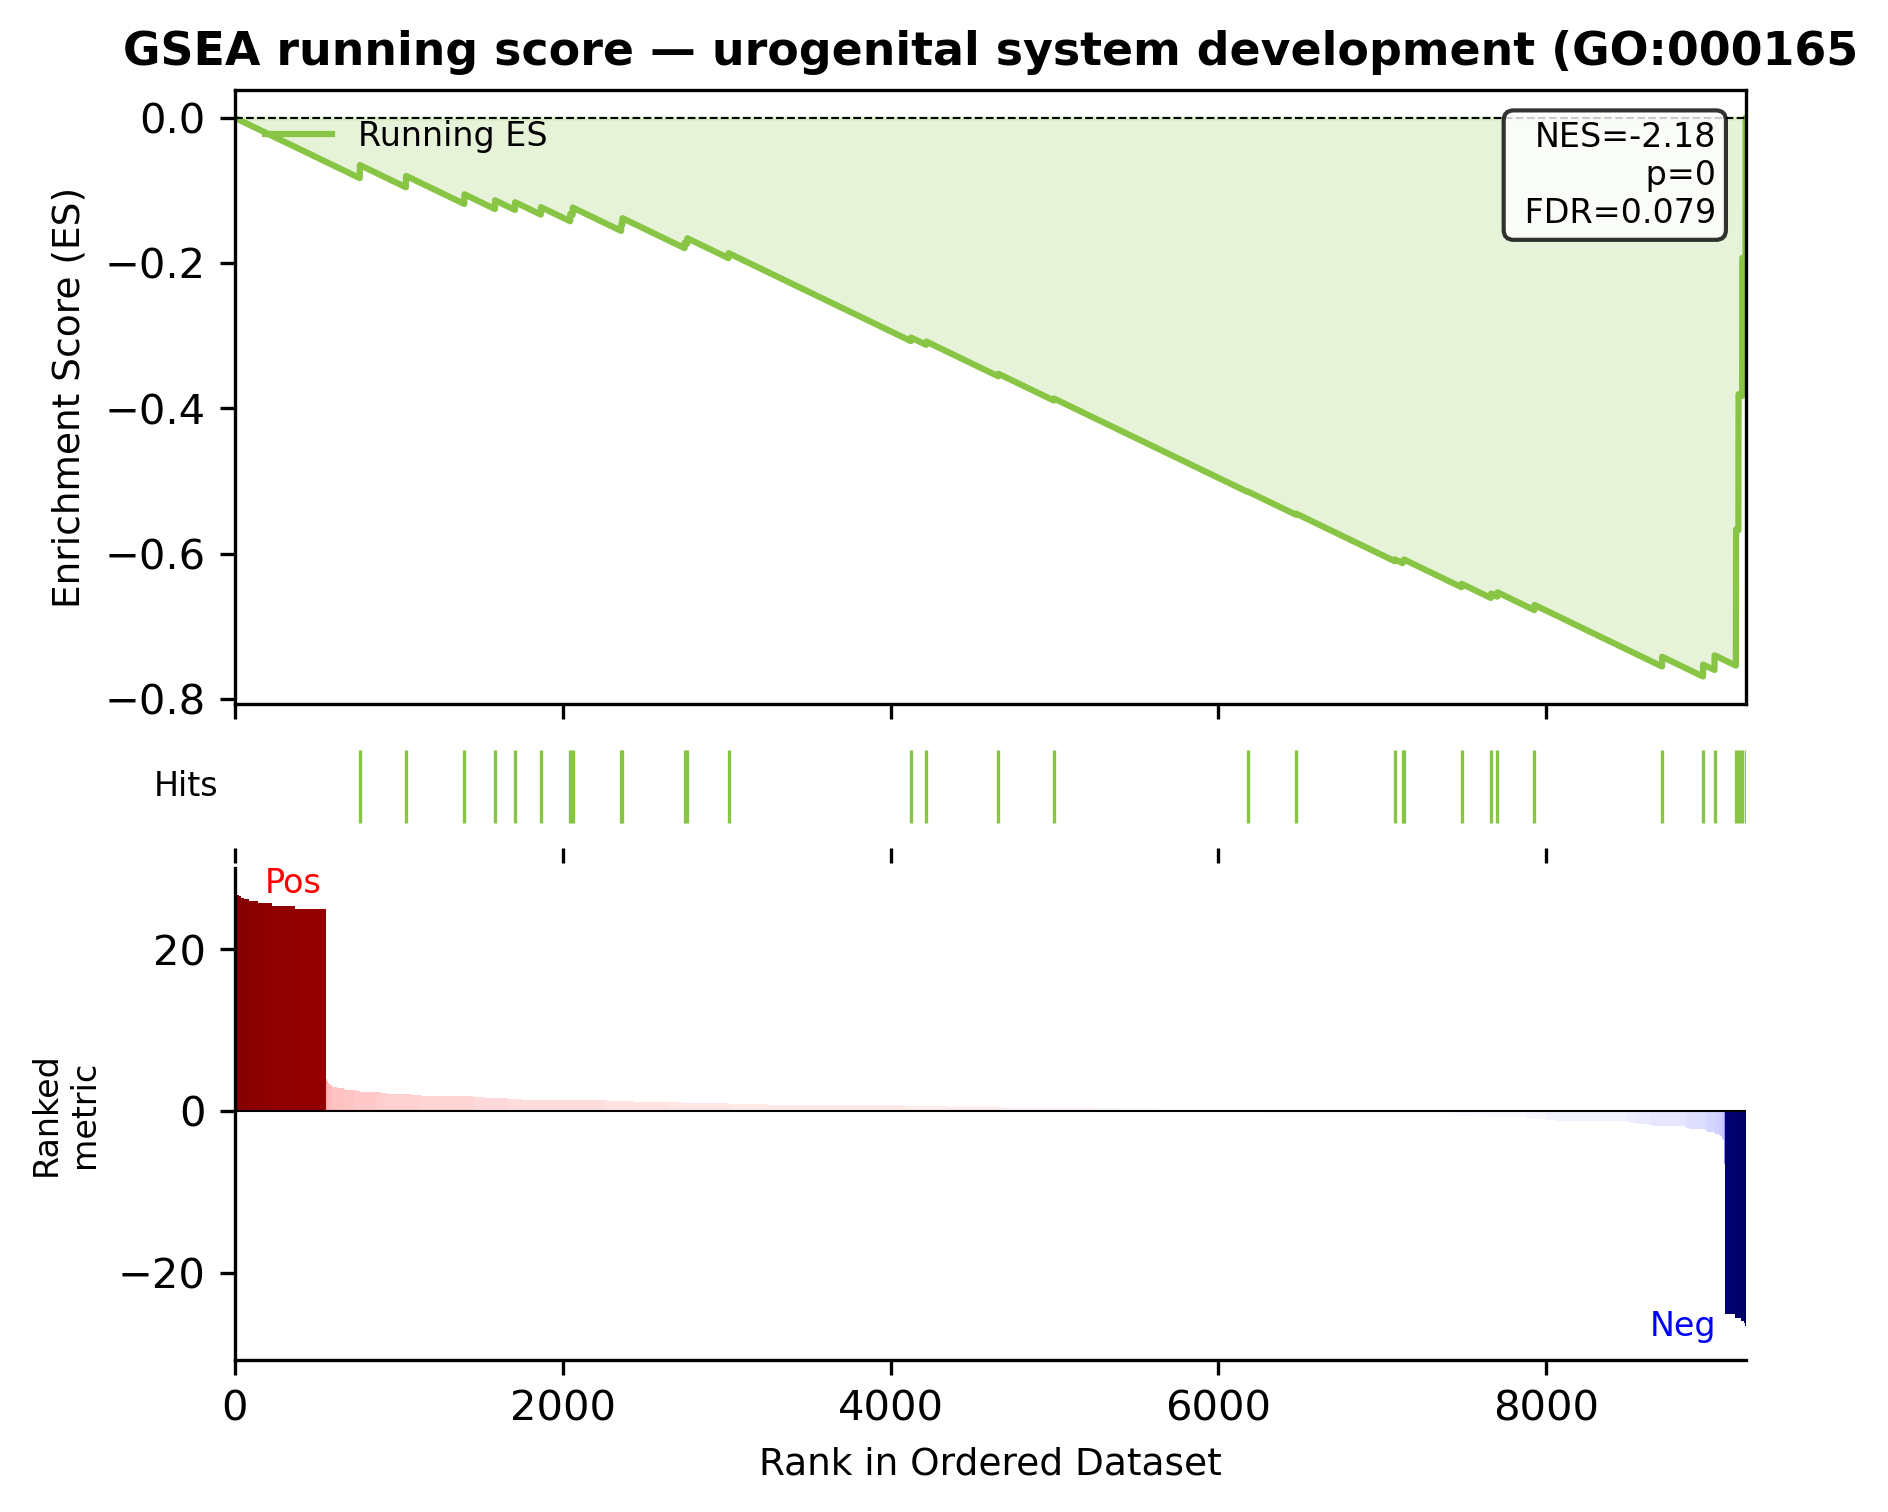

In [20]:
top_term = gsea_res.iloc[0]["Term"]
scat.pl.gseaplot(ranked, gsea_res, term=top_term, title=f"GSEA running score — {top_term[:40]}");

In [21]:
simplified_jaccard = scat.simplify_enrichment(
    go_res, method="jaccard", similarity_cutoff=0.5, min_count=3,
)
print(f"jaccard: {len(go_res)} -> {len(simplified_jaccard)} terms")

simplified_denester = scat.simplify_enrichment(
    go_res, method="pathway_denester", min_count=3,
)
print(f"pathway_denester: {len(go_res)} -> {len(simplified_denester)} terms")

jaccard: 6744 -> 162 terms
pathway_denester: 6744 -> 130 terms


### Comparing gene sets: `compare_enrichment` + `concat_compare_results`

`compare_enrichment` runs ORA across several named gene lists at once
(clusterProfiler's `compareCluster` style) and returns a single table with a
`Cluster` column — exactly the shape `enrich_upsetplot` / `enrich_vennplot`
expect. Here we compare the **up**- vs. **down**-regulated candidate genes.

In [22]:
cmp_res = scat.compare_enrichment(
    {"up": candidate_genes, "down": down_genes},
    organism="mouse",
    gene_sets="GO_Biological_Process",
    adata=adata_norm,
)
cmp_res["Cluster"].value_counts()

Cluster
up    47
Name: count, dtype: int64

`concat_compare_results` does the same thing when you already have
separate result tables in hand (e.g. combining our GO and KEGG results
above into one comparable table):

In [23]:
concat_res = scat.concat_compare_results({"GO": go_res, "KEGG": kegg_res})
concat_res["Cluster"].value_counts()

Cluster
GO      6744
KEGG     202
Name: count, dtype: int64

### Exporting results

`save_enrichment_report` writes CSV/TSV/Excel + a metadata JSON (gene-set
provenance, universe info, package version); `expand_enrichment_genes`
pivots to one row per gene for network/follow-up analyses. We write to a
scratch temp directory here rather than into the docs tree.

In [24]:
import tempfile, os

tmpdir = tempfile.mkdtemp()
saved_paths = scat.save_enrichment_report(
    kegg_res,
    prefix=os.path.join(tmpdir, "kegg_demo"),
    save_excel=True, save_csv=True, save_tsv=True,
    save_metadata=True, save_term_gene_table=True,
)
saved_paths

{'results_csv': '/tmp/tmplqv4ijao/kegg_demo_results.csv',
 'term_gene_table_csv': '/tmp/tmplqv4ijao/kegg_demo_term_gene_table.csv',
 'results_tsv': '/tmp/tmplqv4ijao/kegg_demo_results.tsv',
 'term_gene_table_tsv': '/tmp/tmplqv4ijao/kegg_demo_term_gene_table.tsv',
 'metadata_json': '/tmp/tmplqv4ijao/kegg_demo_metadata.json',
 'results_xlsx': '/tmp/tmplqv4ijao/kegg_demo_results.xlsx'}

In [25]:
long_table = scat.expand_enrichment_genes(kegg_res)
print(long_table.shape)
long_table.head()

(146, 14)


,Term,Description,Gene,Count,GeneRatio,GeneRatio_str,BgRatio,BgRatio_str,FoldEnrichment,RichFactor,Overlap,pvalue,p.adjust,TermSize
0,Ribosome(mmu03010),,Rpl14,21,0.333333,21/63,0.029197,84/2877,11.416667,0.25,21/84,4.654655e-18,9.402402e-16,84
1,Ribosome(mmu03010),,Rpl18a,21,0.333333,21/63,0.029197,84/2877,11.416667,0.25,21/84,4.654655e-18,9.402402e-16,84
2,Ribosome(mmu03010),,Rpl21,21,0.333333,21/63,0.029197,84/2877,11.416667,0.25,21/84,4.654655e-18,9.402402e-16,84
3,Ribosome(mmu03010),,Rpl23a,21,0.333333,21/63,0.029197,84/2877,11.416667,0.25,21/84,4.654655e-18,9.402402e-16,84
4,Ribosome(mmu03010),,Rpl26,21,0.333333,21/63,0.029197,84/2877,11.416667,0.25,21/84,4.654655e-18,9.402402e-16,84


## Plotting gallery

Every `scat.pl.*` function below accepts `ax=`, `save_path=`, `show=`,
`figsize=`, and `use_style=` for embedding in multi-panel publication
figures (see {doc}`../user_guide/plotting`).

### Volcano plots (3 styles)

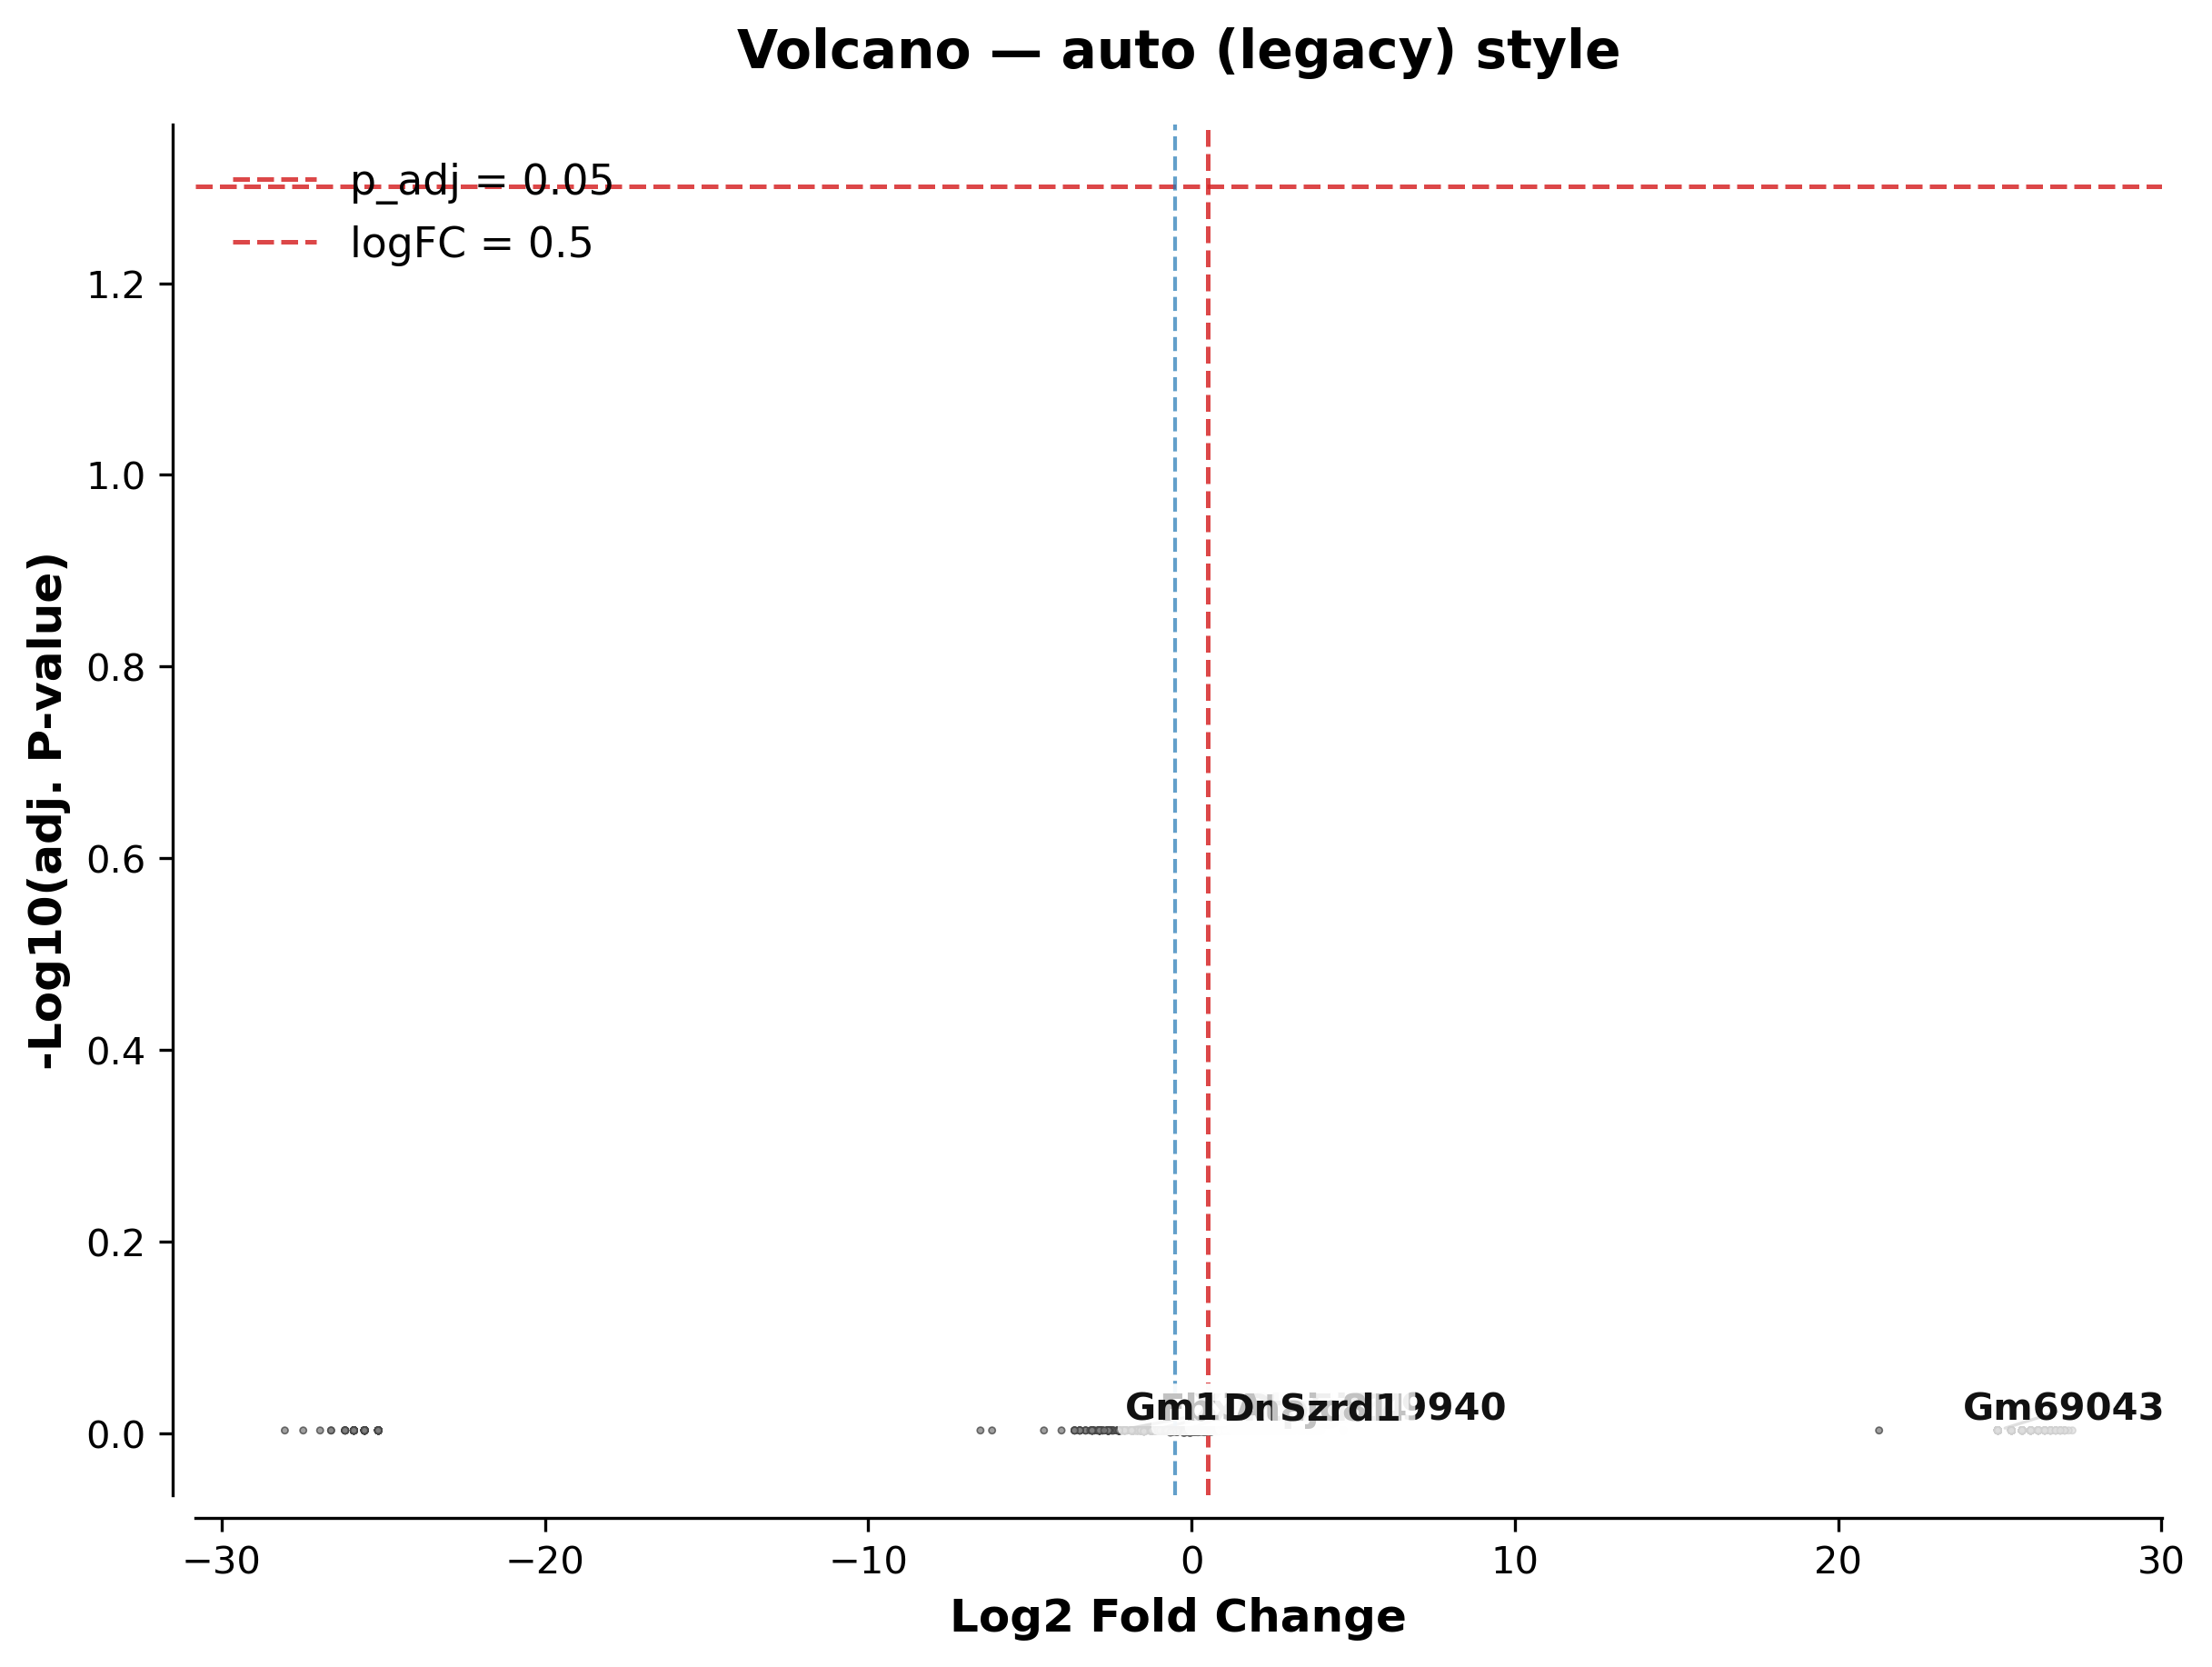

In [26]:
scat.pl.volcano_plot(de_wilcoxon, style="auto", top_n=10, title="Volcano — auto (legacy) style");

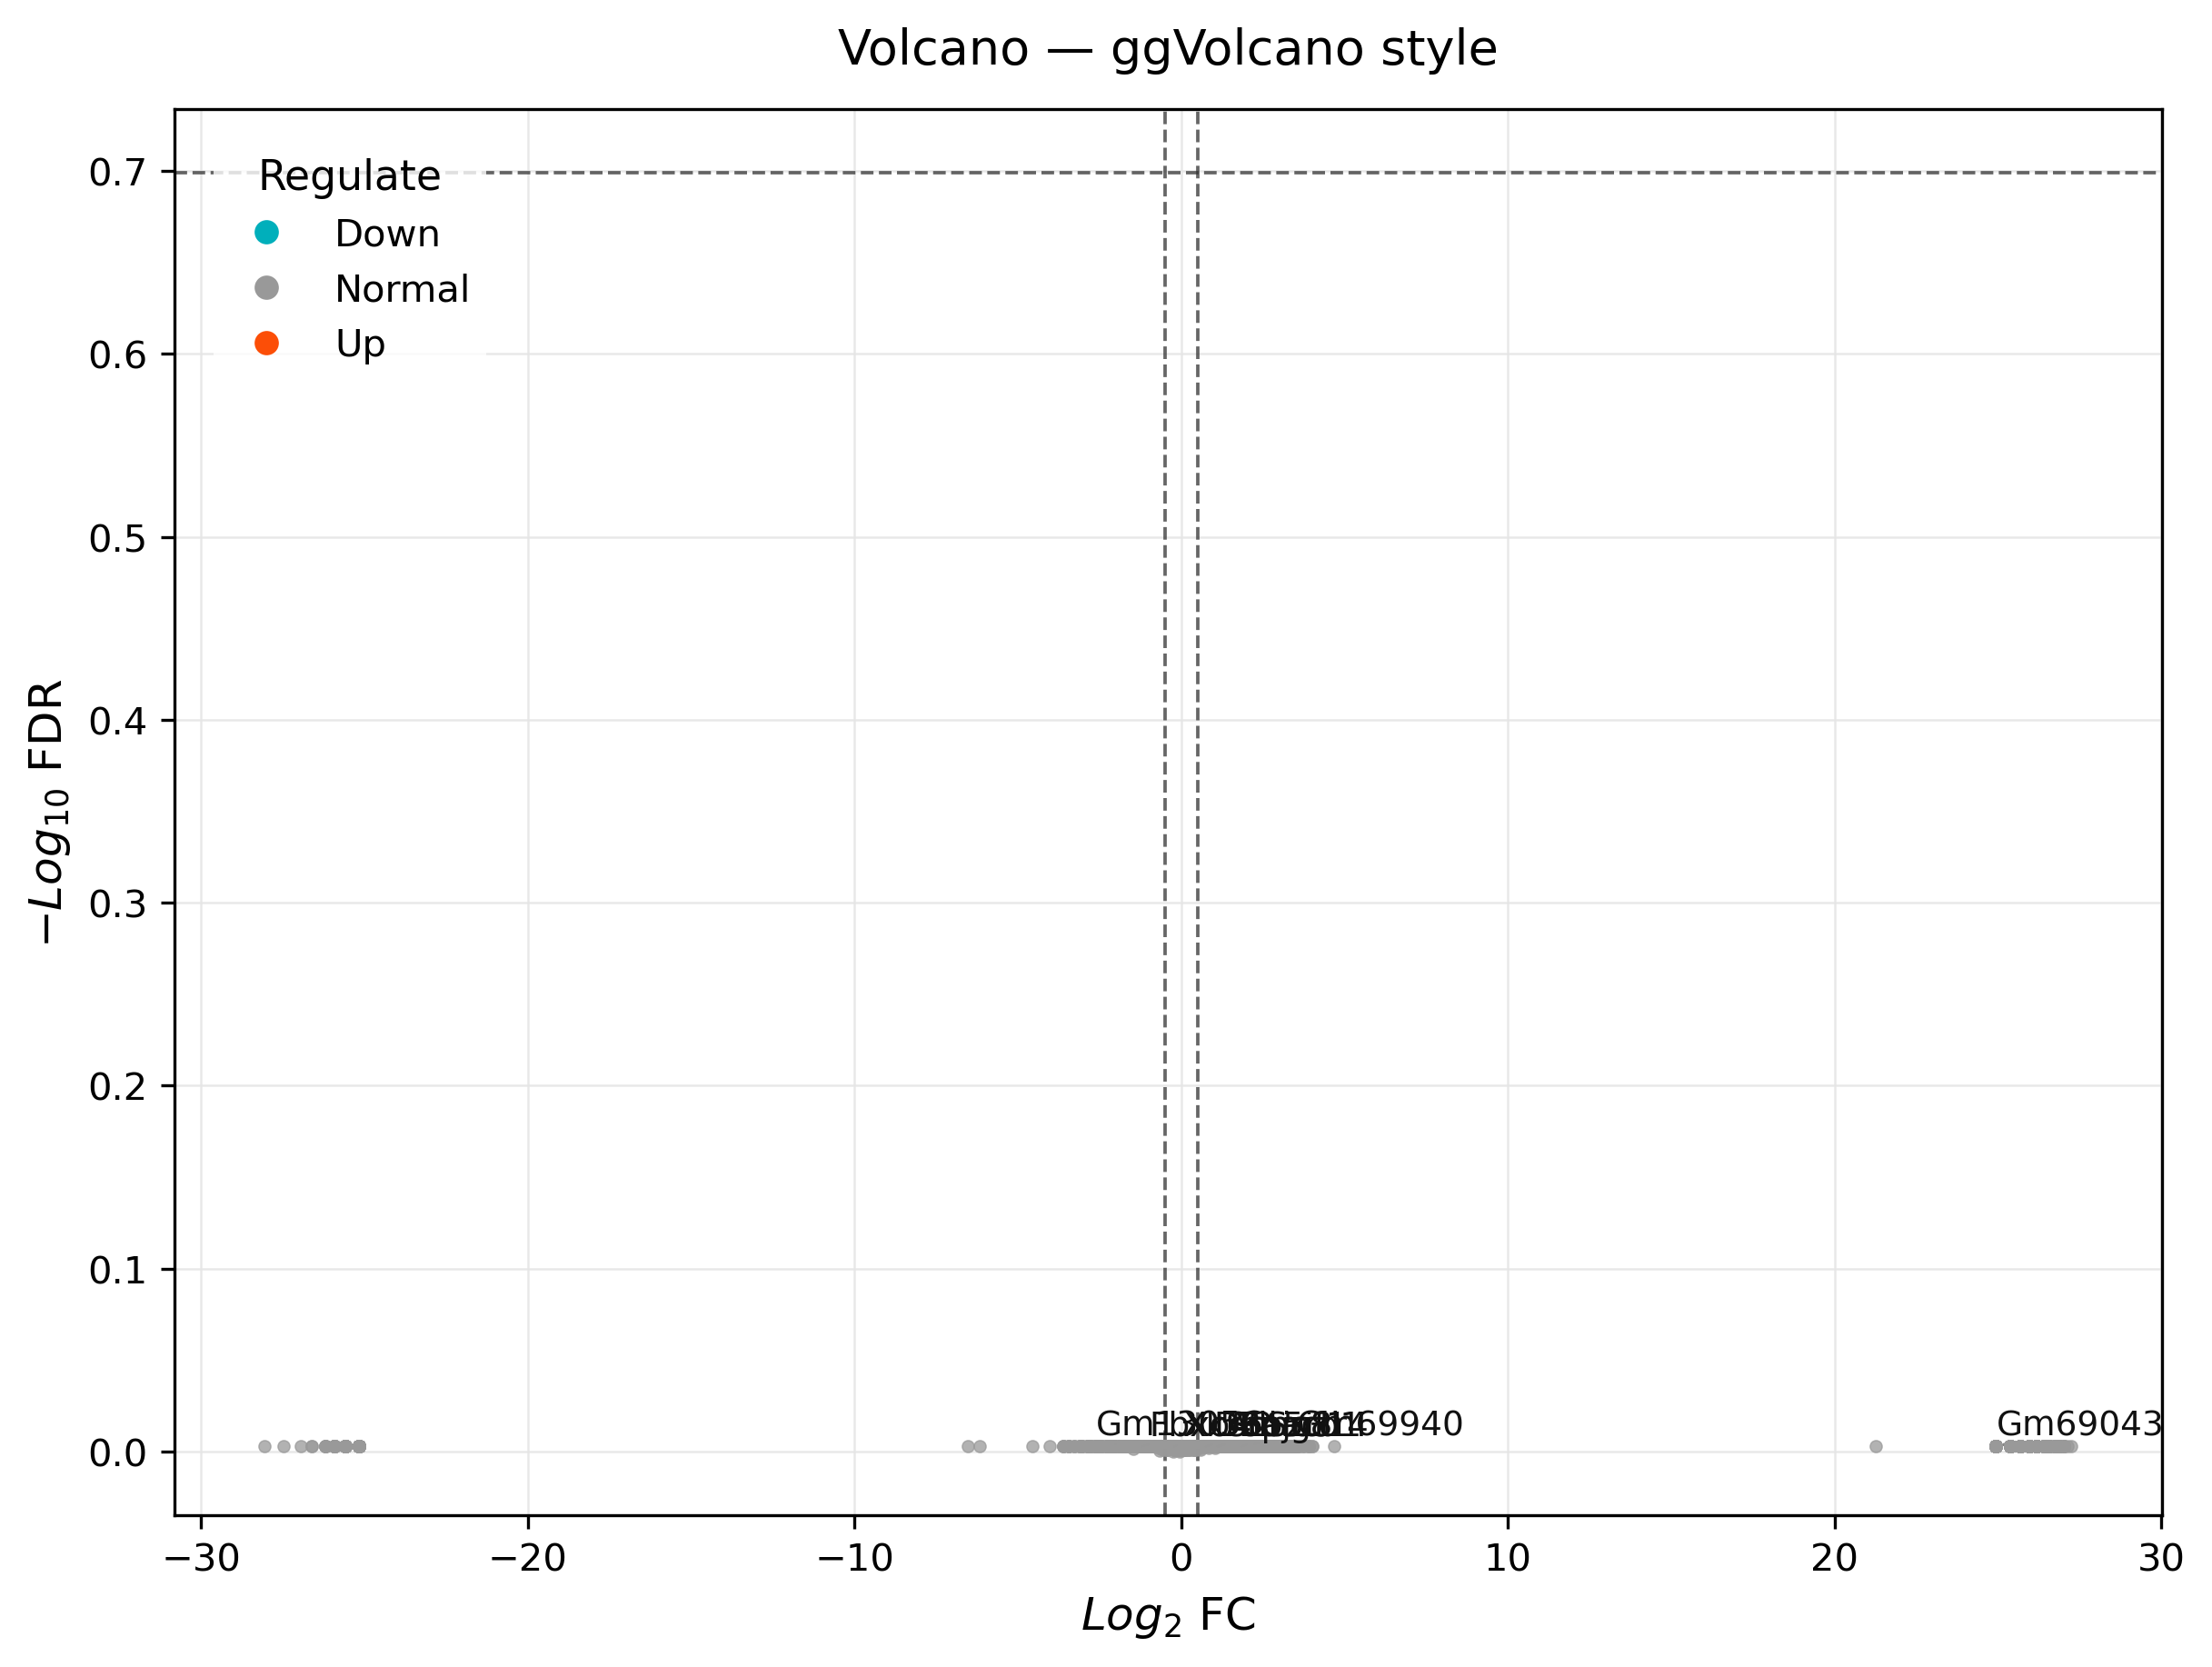

In [27]:
scat.pl.volcano_plot(
    de_wilcoxon, style="ggvolcano", top_n=10, logfc_cutoff=0.5, pval_cutoff=0.2,
    title="Volcano — ggVolcano style",
);

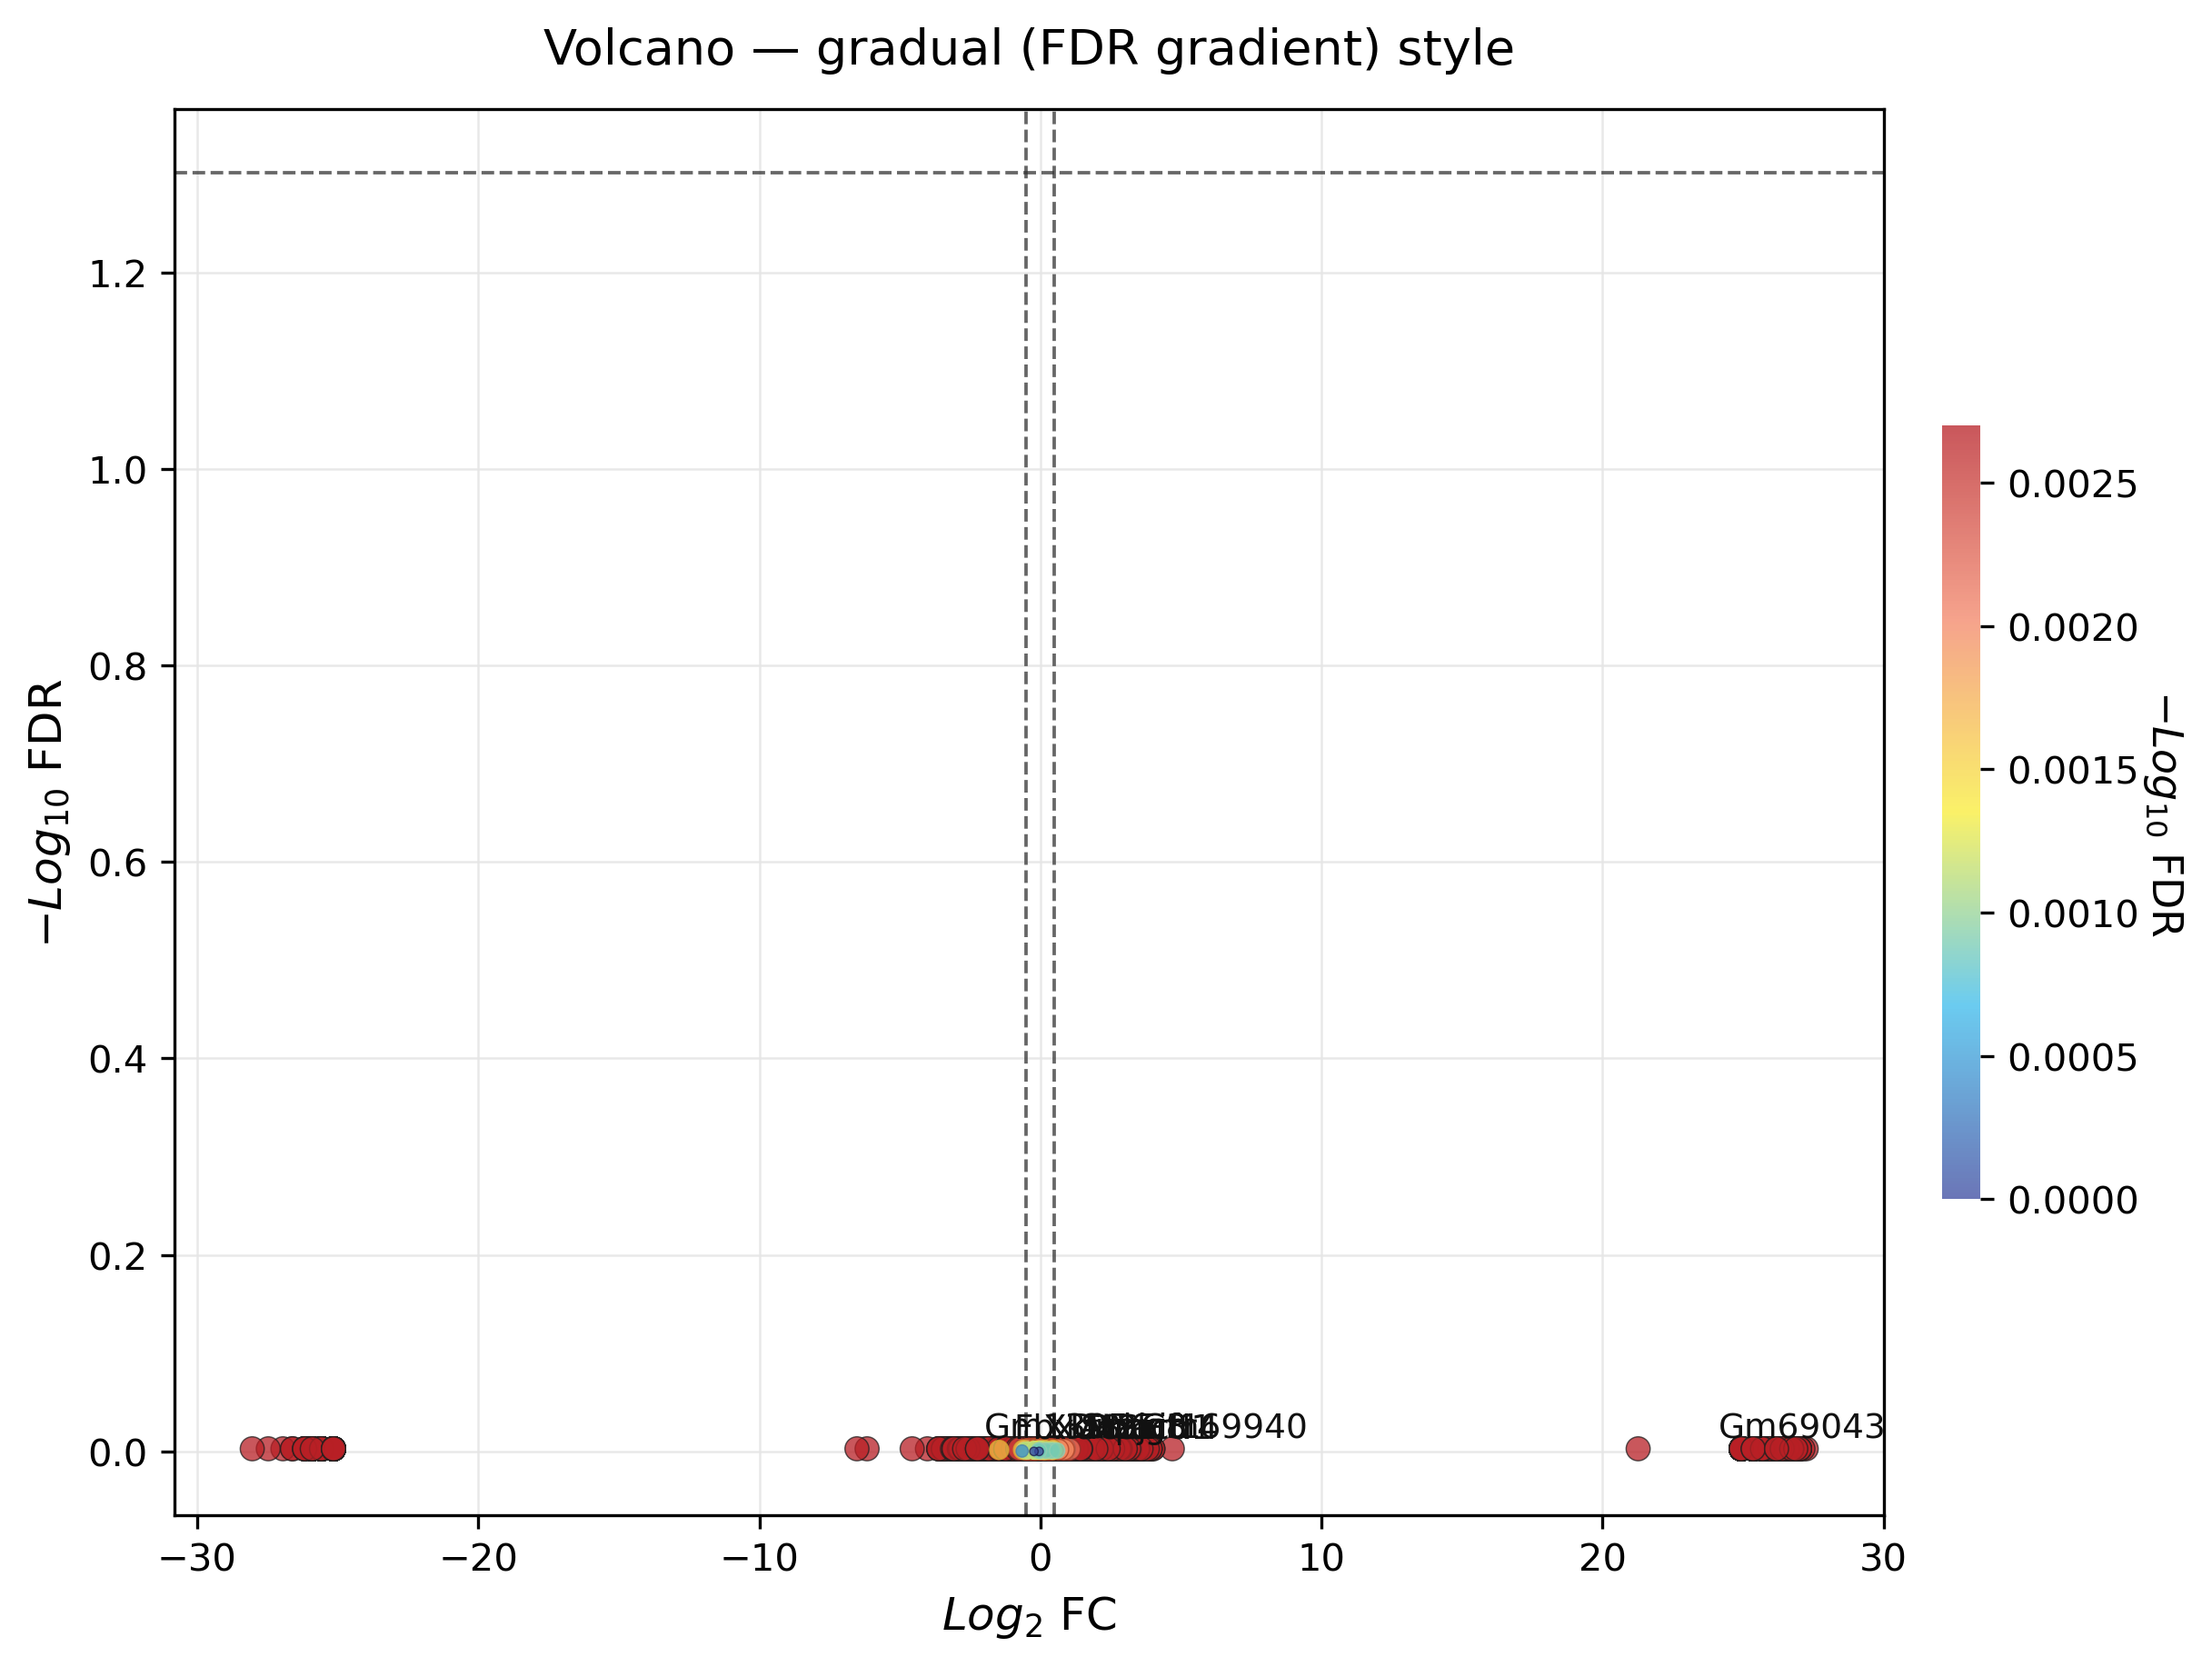

In [28]:
scat.pl.volcano_plot(de_wilcoxon, style="gradual", top_n=10, title="Volcano — gradual (FDR gradient) style");

### Enrichment dot plots and bar plot

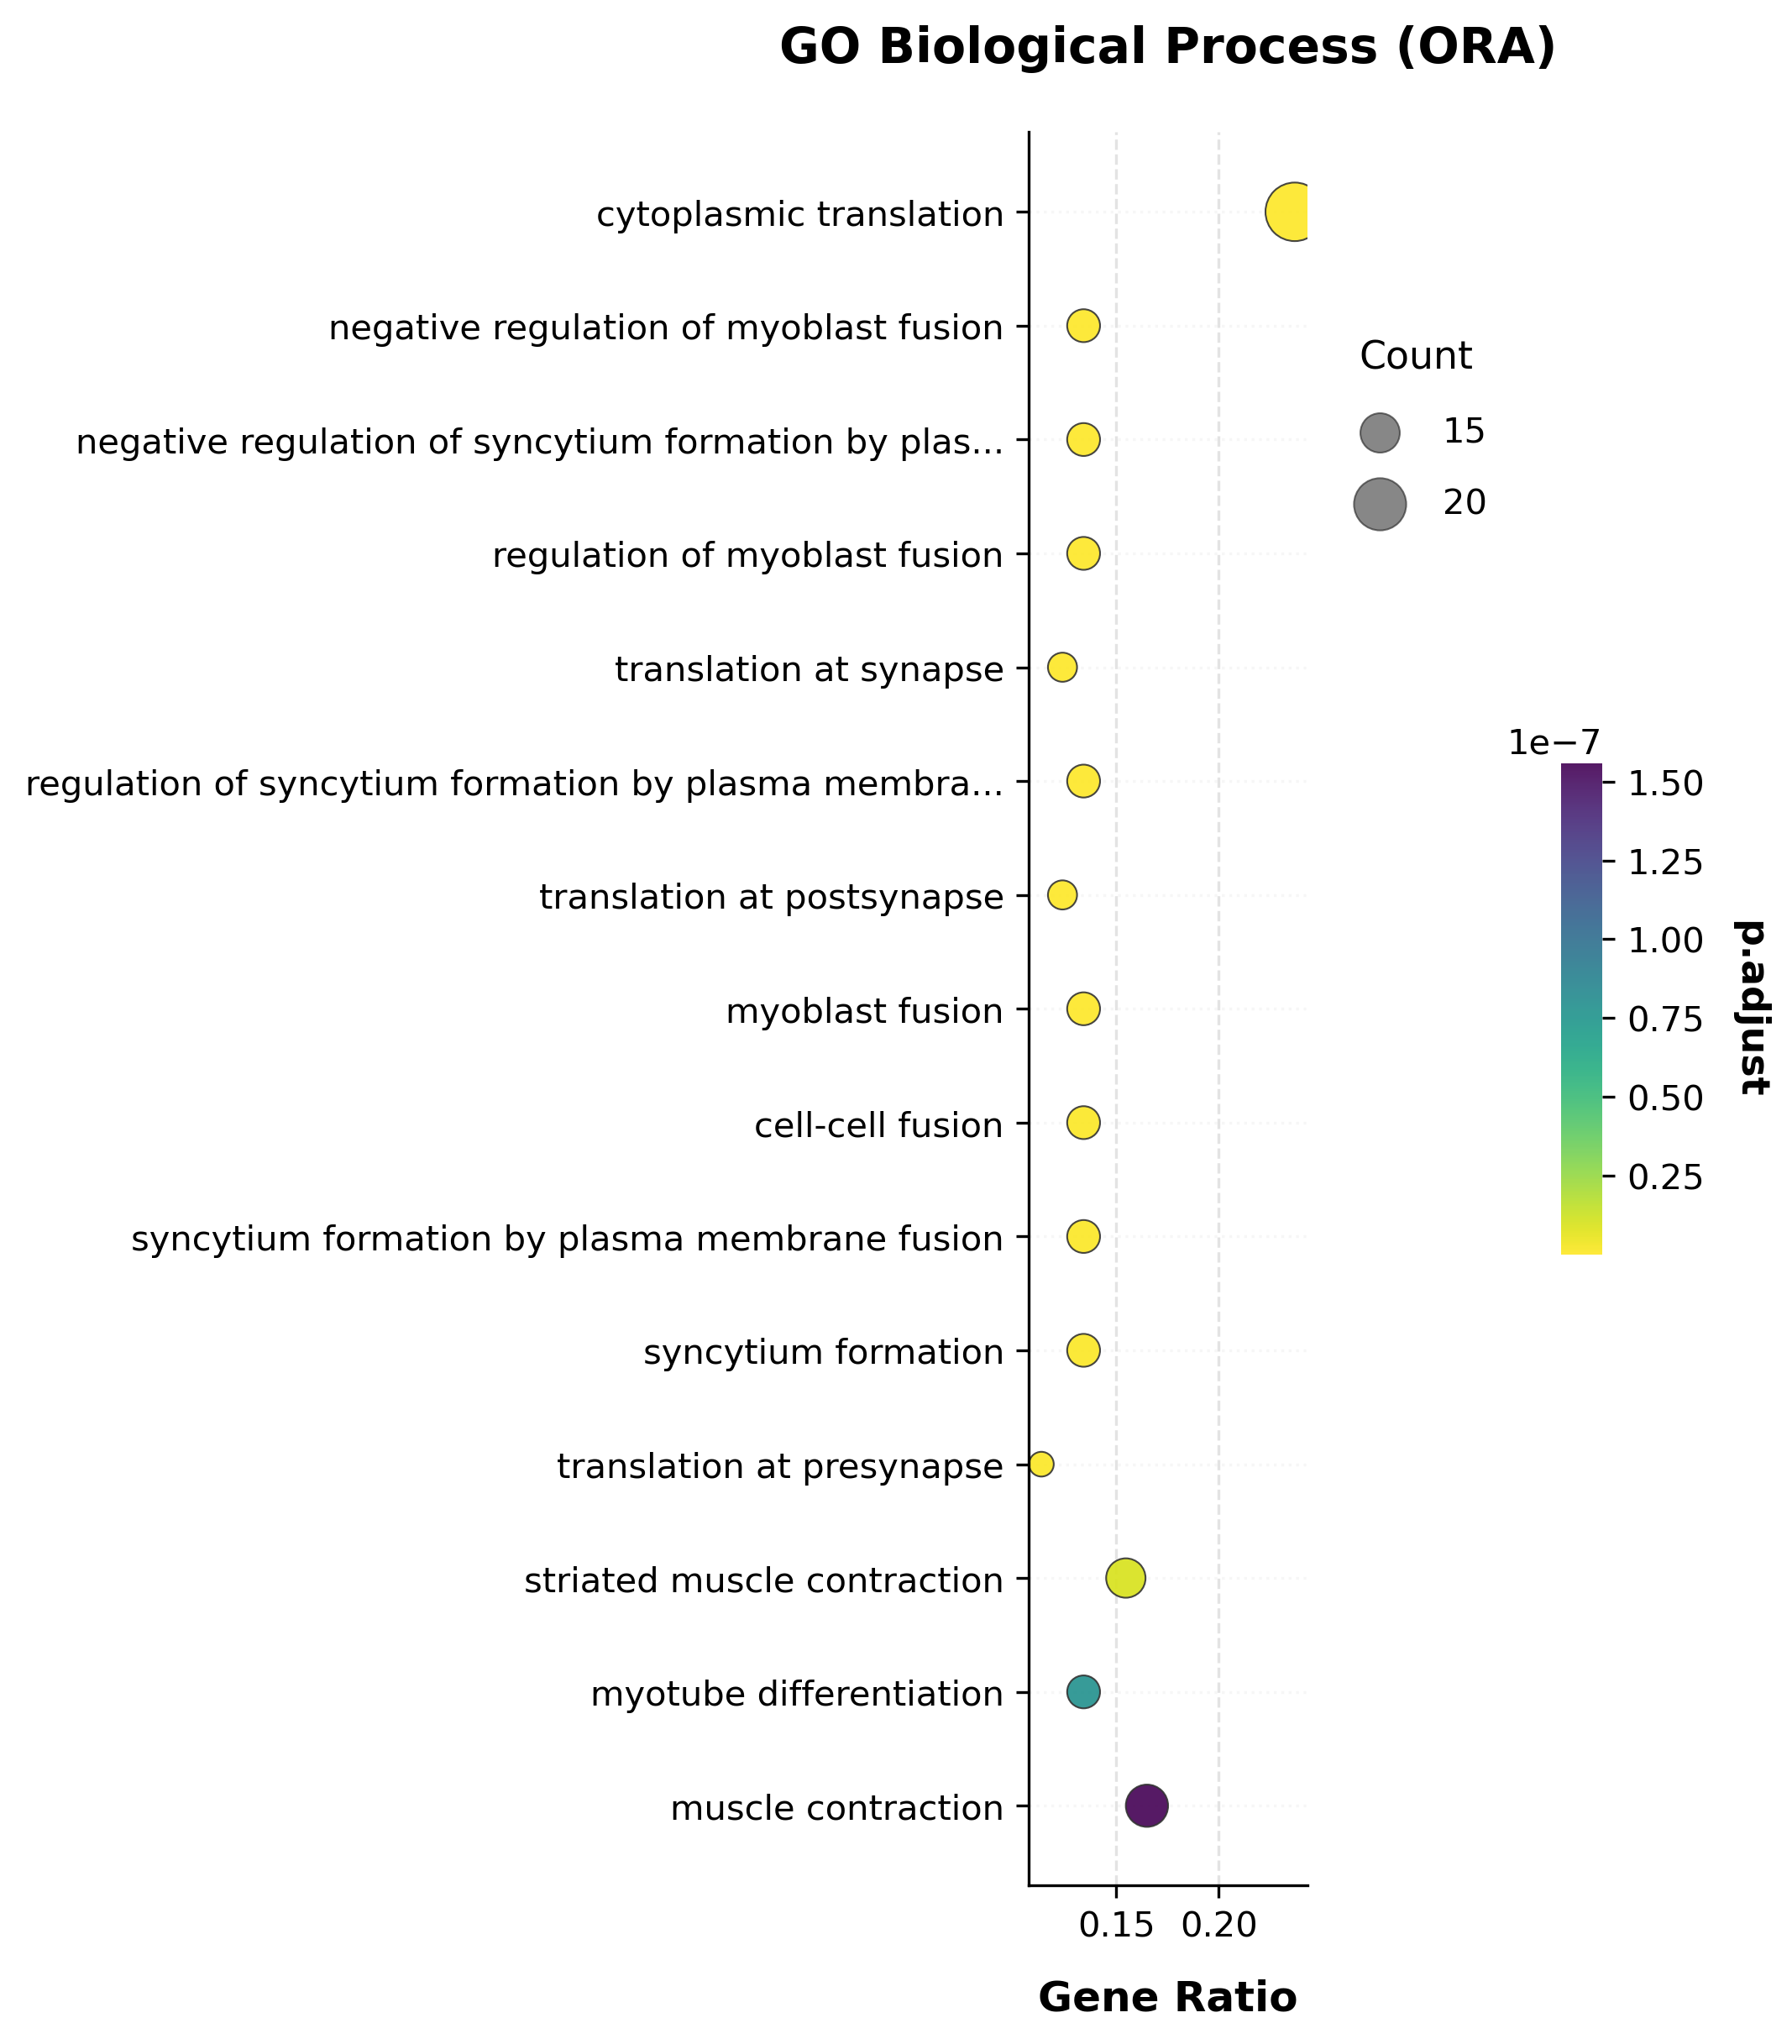

In [29]:
scat.pl.enrich_dotplot(go_res, top_n=15, title="GO Biological Process (ORA)");

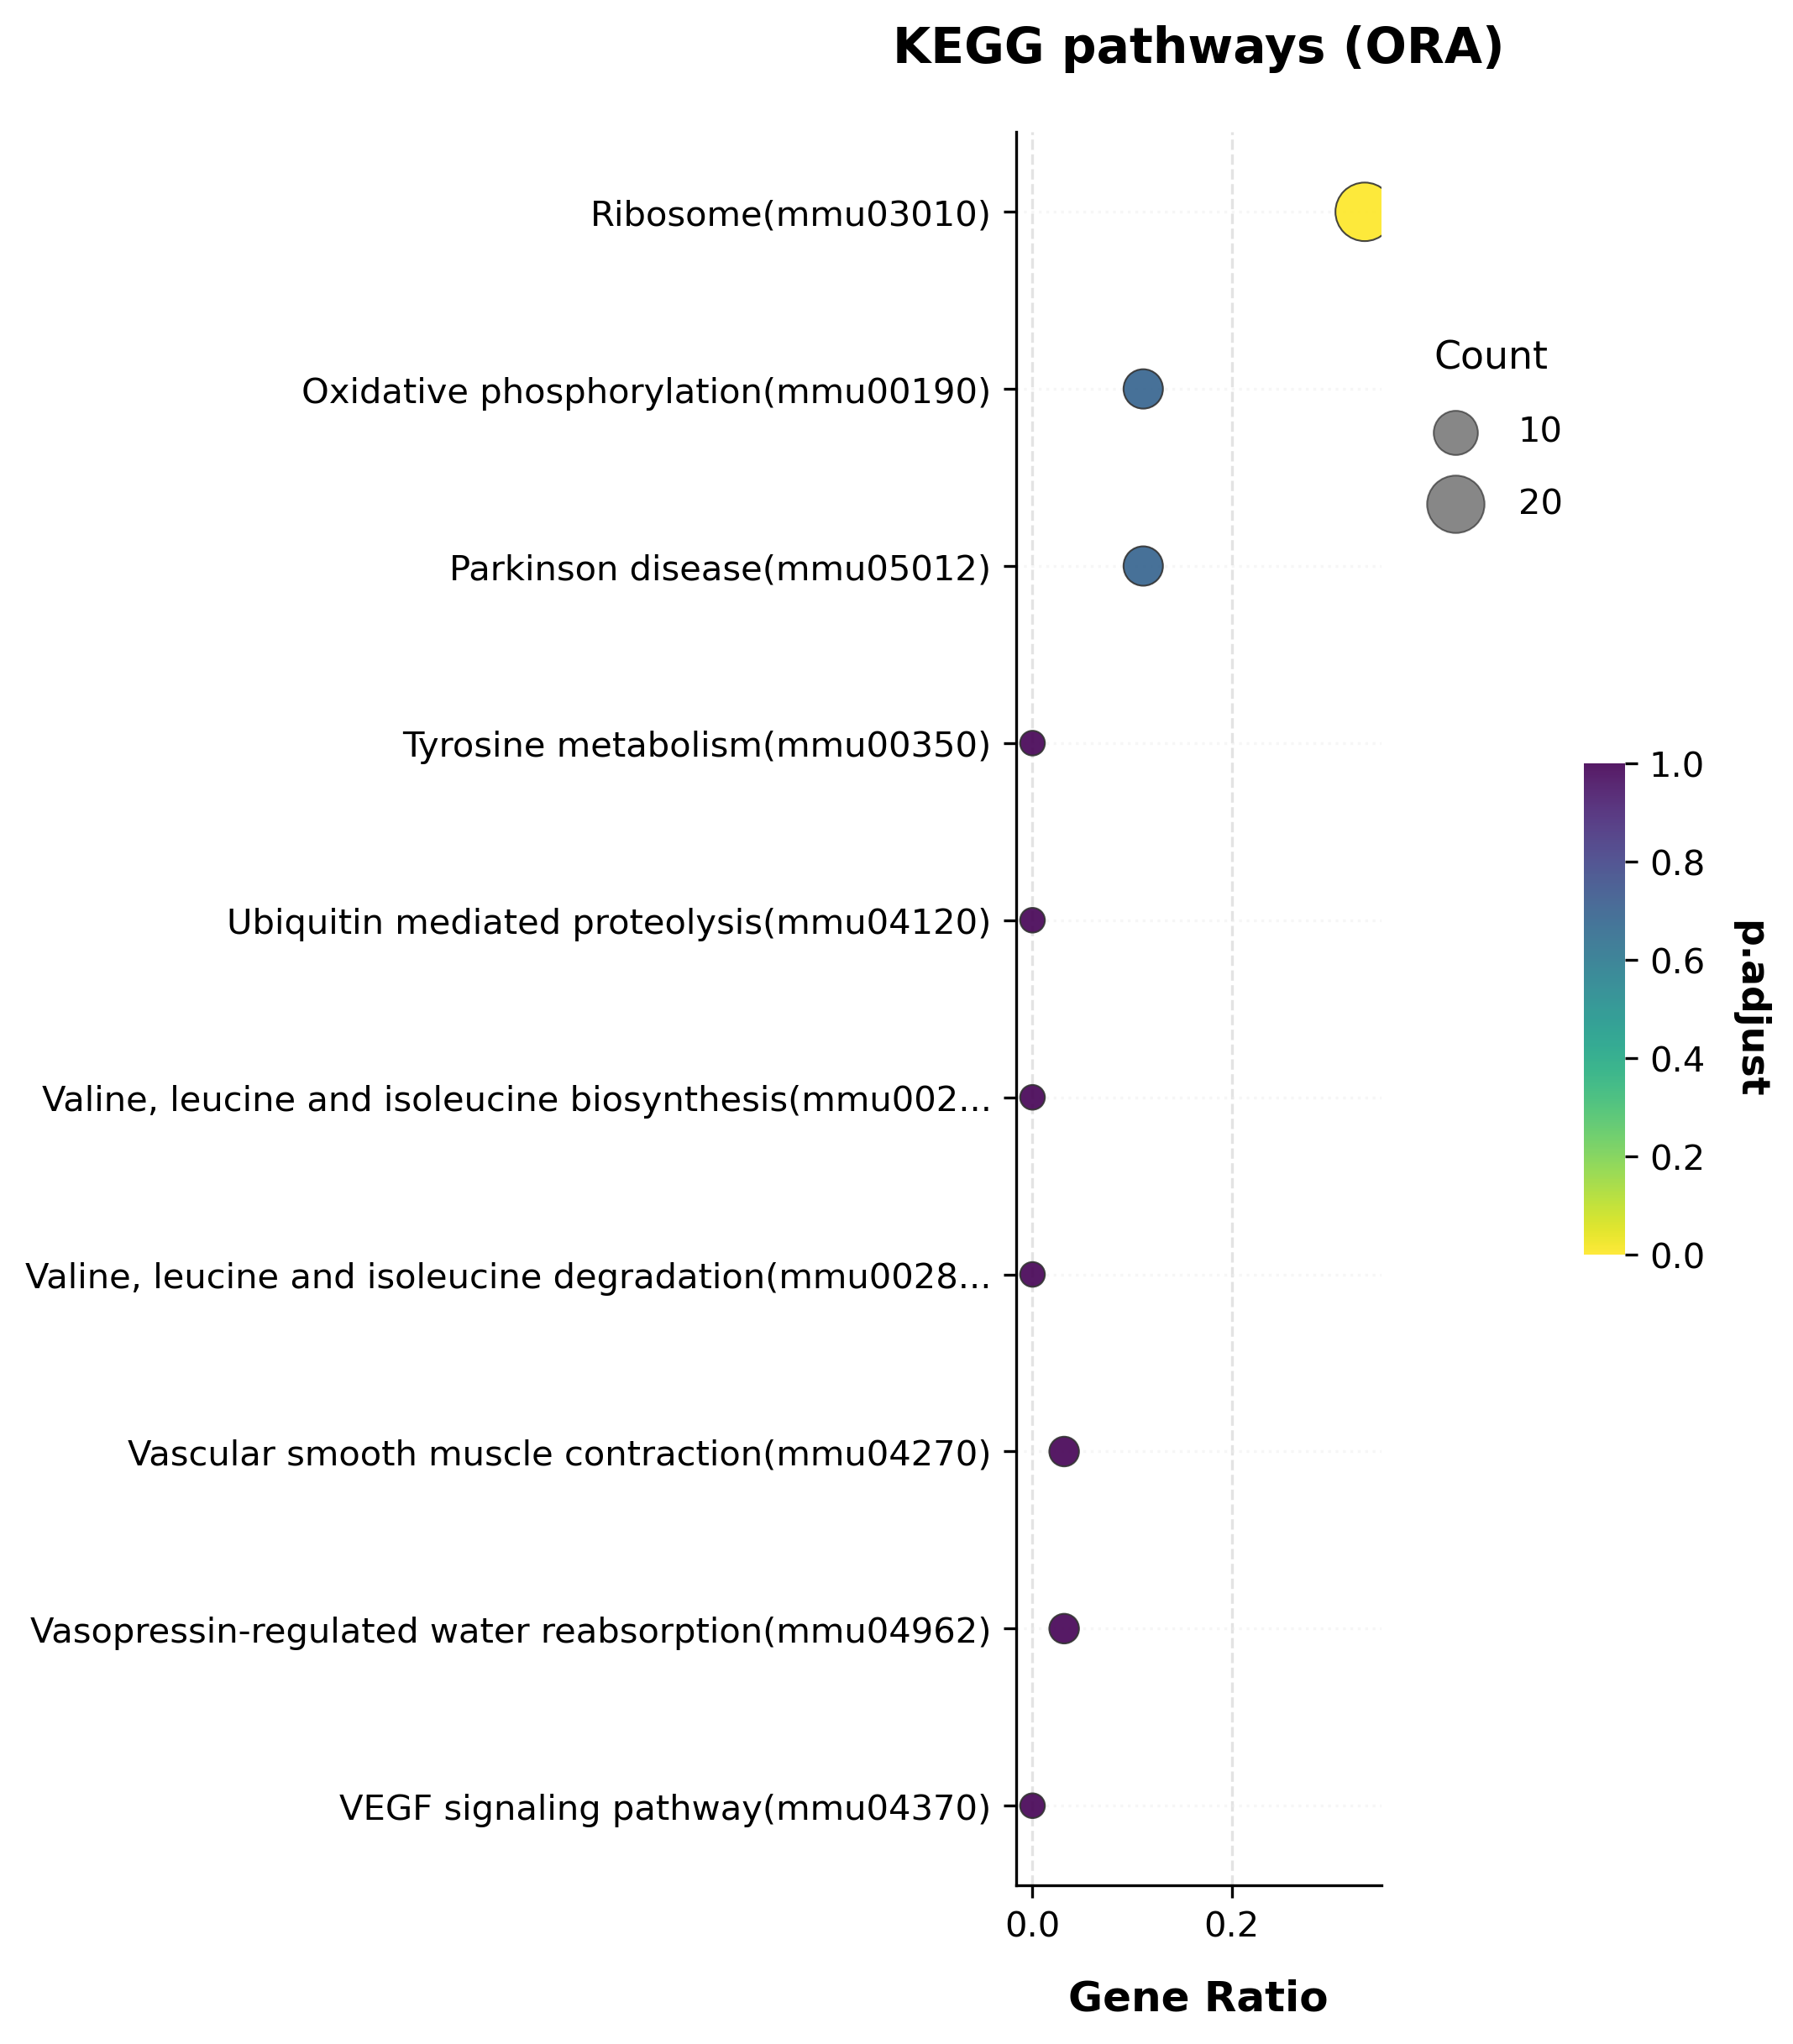

In [30]:
scat.pl.enrich_dotplot(kegg_res, top_n=10, title="KEGG pathways (ORA)");

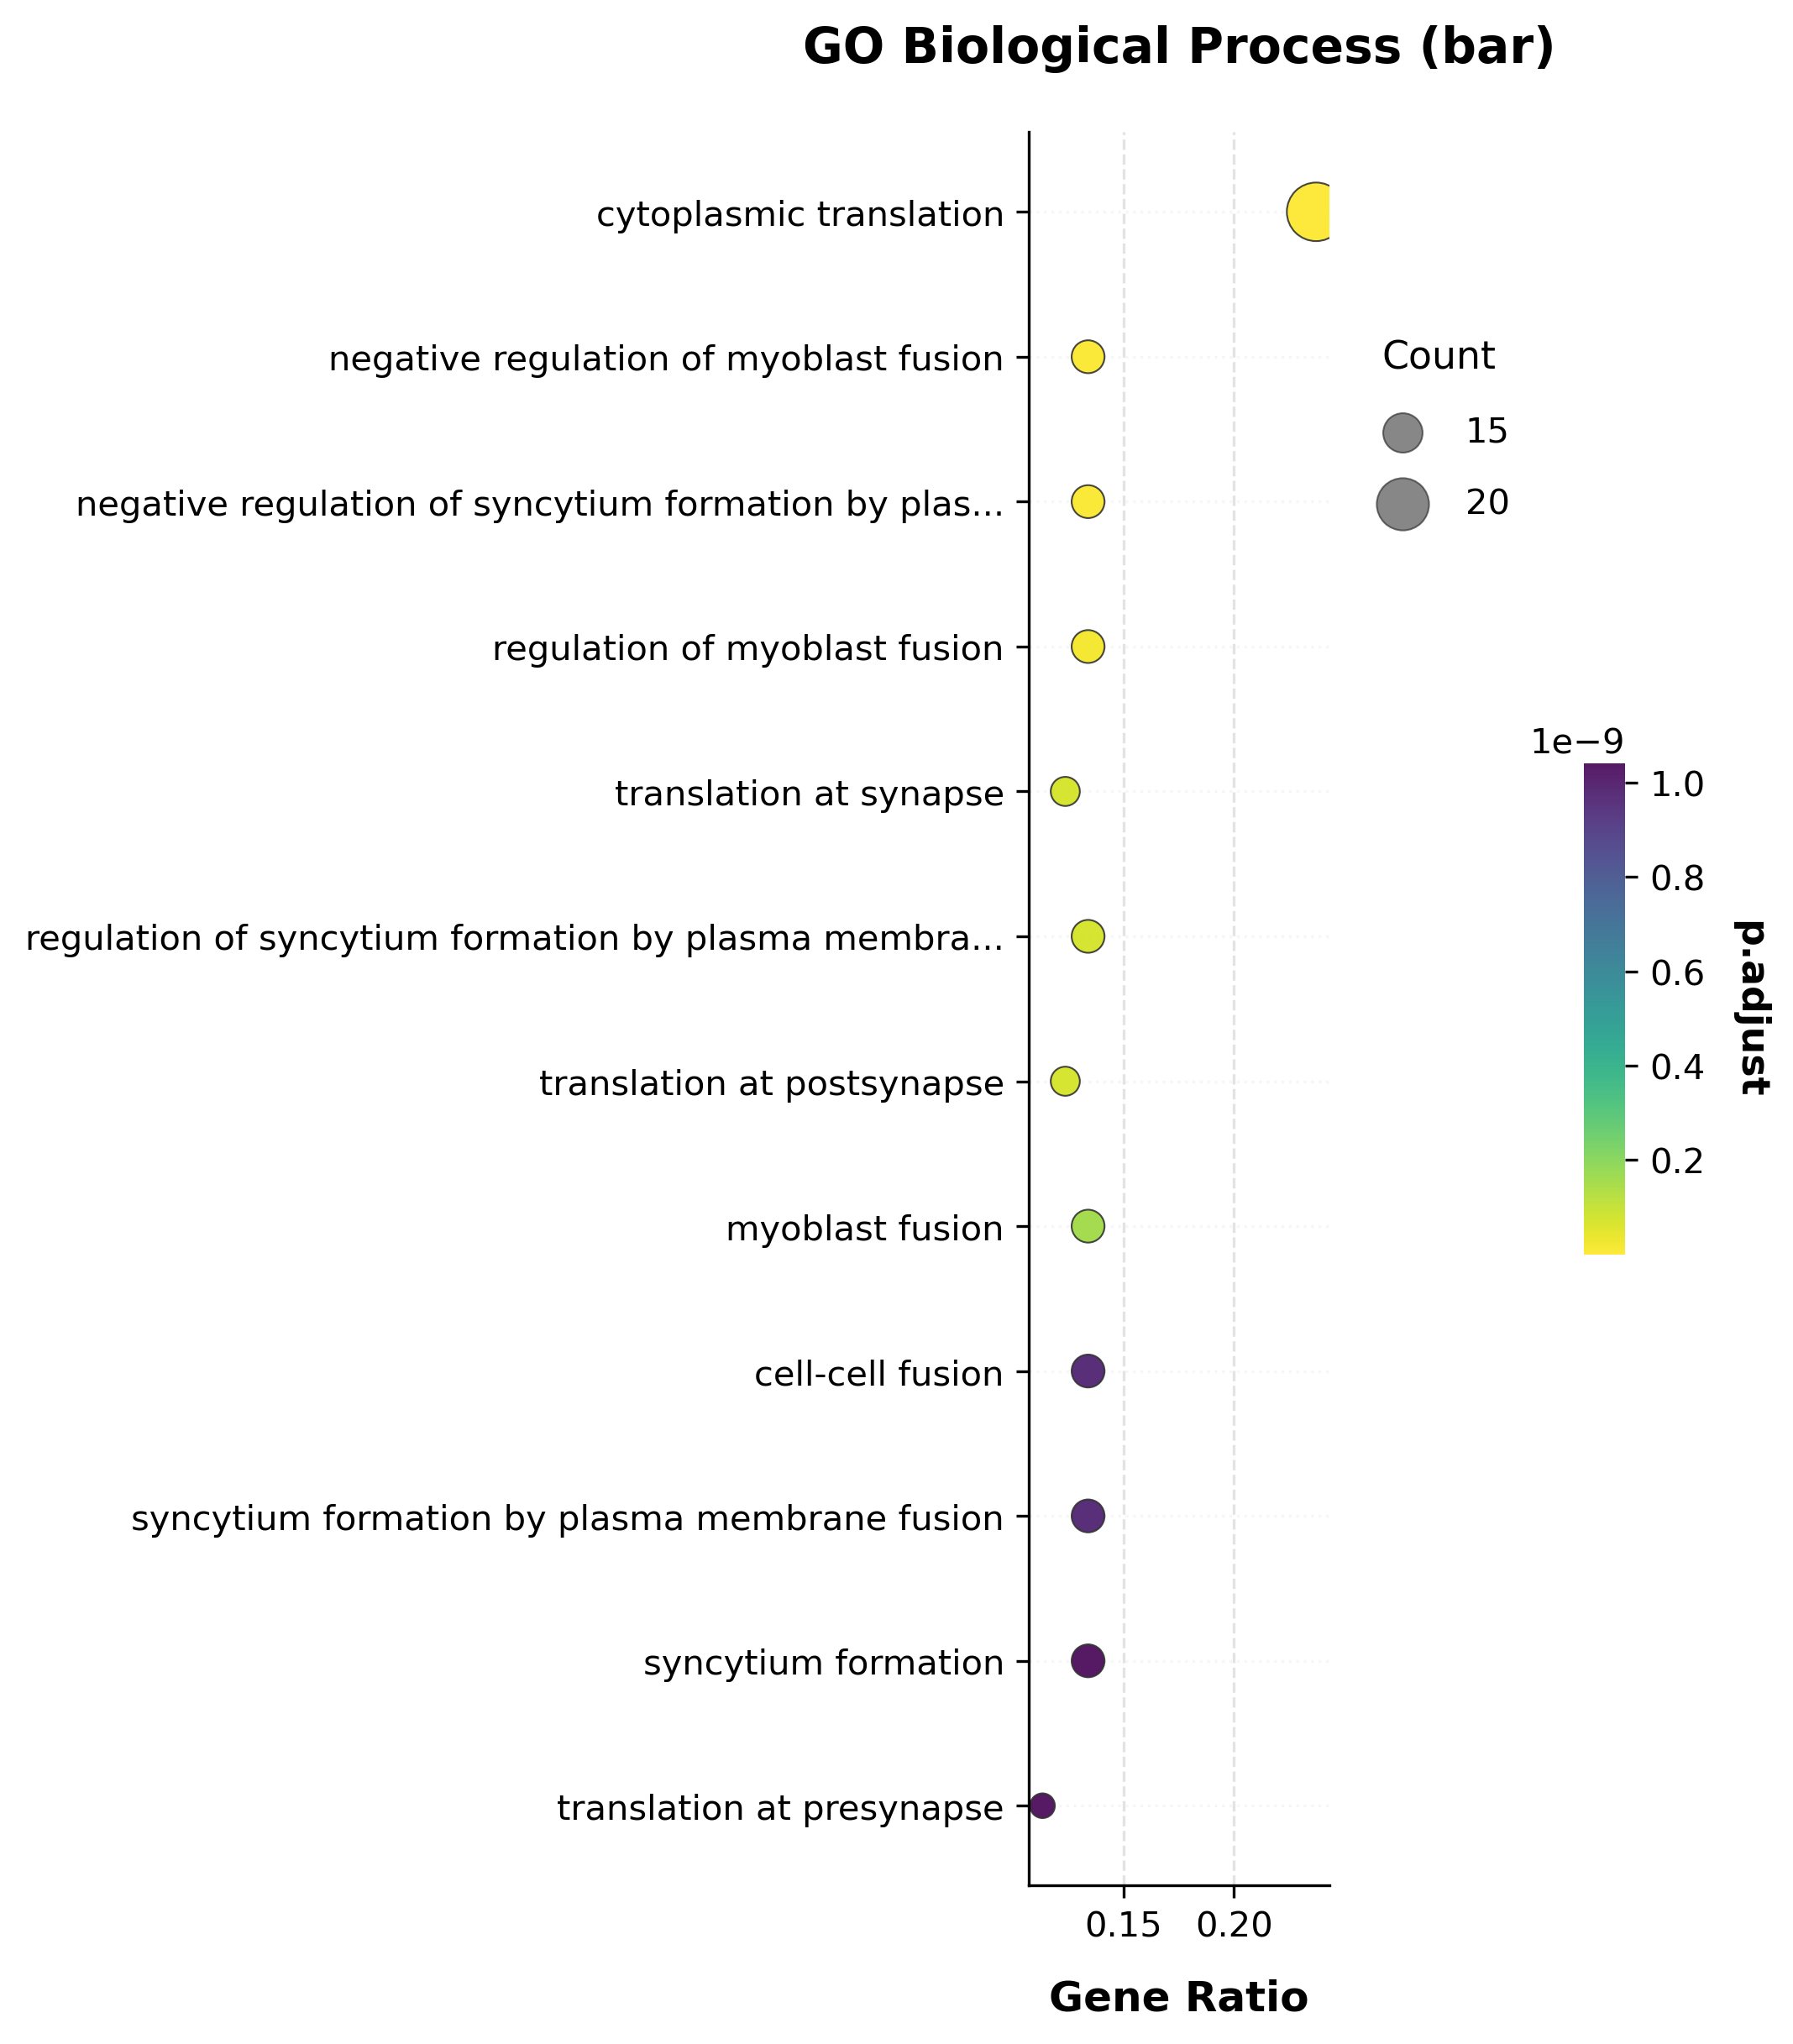

In [31]:
scat.pl.enrich_barplot(go_res, top_n=12, title="GO Biological Process (bar)");

### UpSet and Venn: comparing up- vs. down-regulated enrichment

Built for `compare_enrichment`/`concat_compare_results` output (a `Cluster`
column identifies each group).

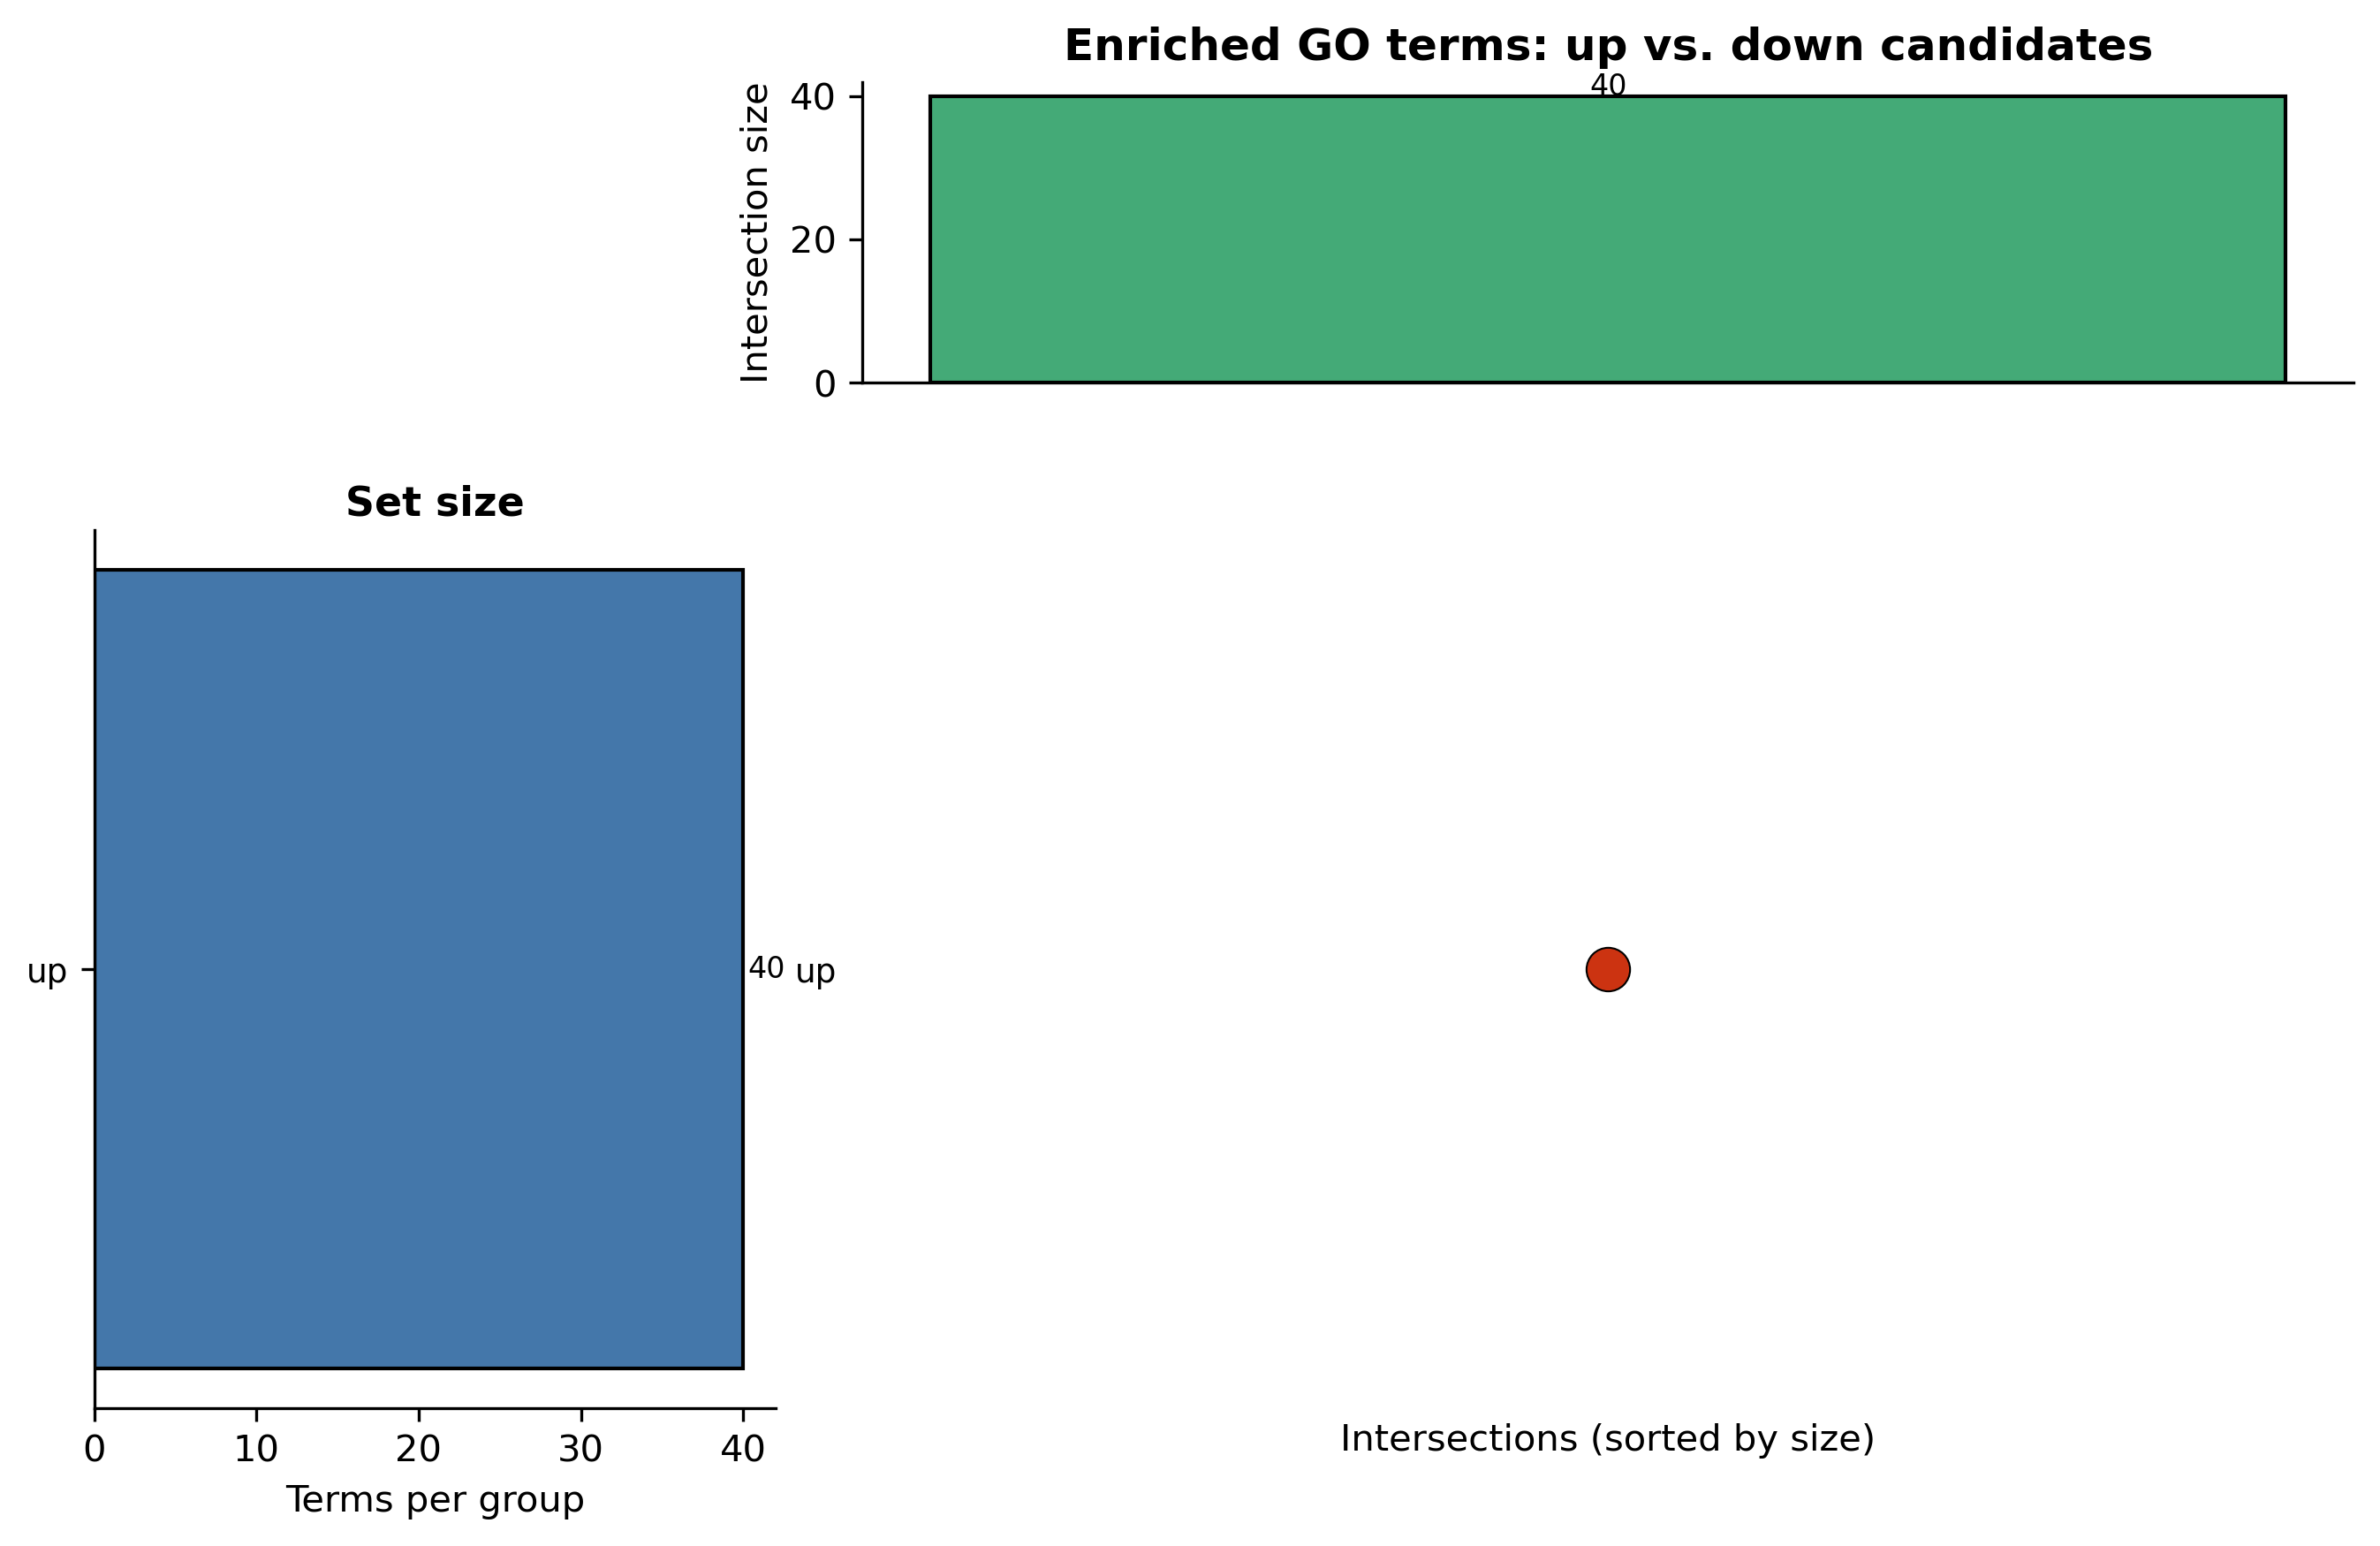

In [32]:
scat.pl.enrich_upsetplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: up vs. down candidates");

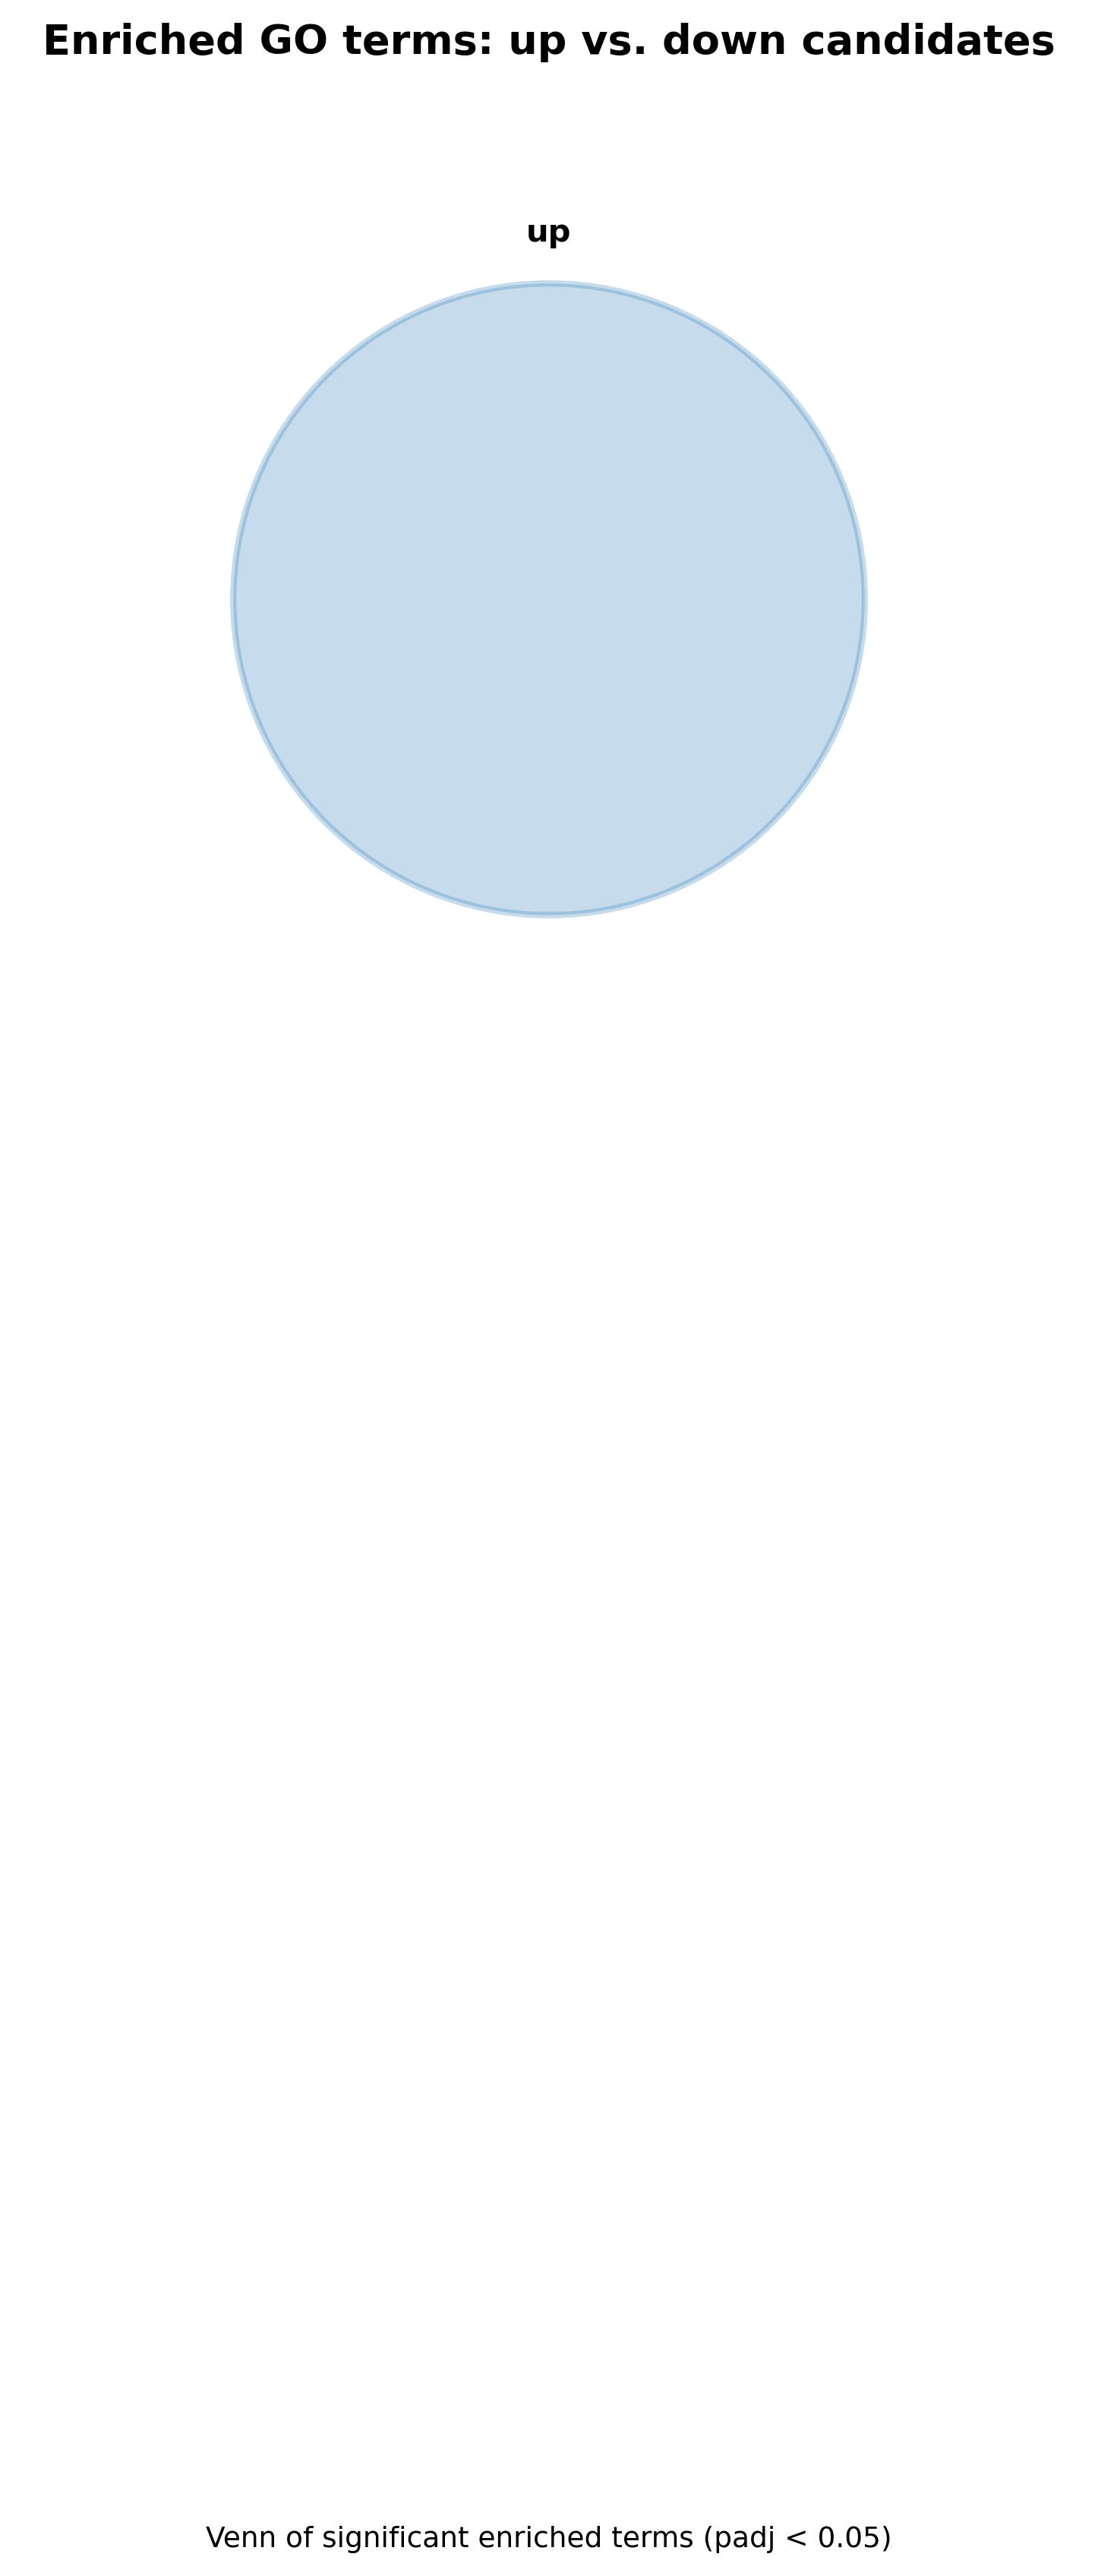

In [33]:
scat.pl.enrich_vennplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: up vs. down candidates");

### Heatmap of top candidate genes

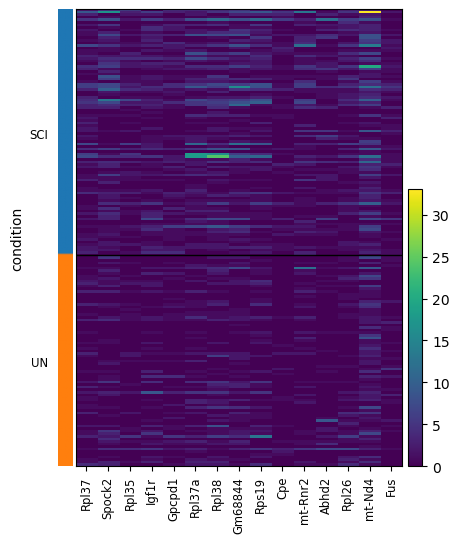

In [34]:
scat.pl.active_genes_heatmap(adata_norm, candidate_genes[:15], groupby="condition");

### Not applicable here

`comet_plot`, `bias_diagnostic_plot`, `active_score_rankplot`,
`velocity_phase_portraits`, and `gamma_shrinkage_plot` all require
`active_score`/`unspliced_excess_*`/`effective_gamma` columns that only
exist on the velocity-aware `active_score` path — see the sibling tutorial
{doc}`t_ec_active_transcription` for those.

## Recap

Without ever touching a spliced/unspliced layer, this notebook covered:

- Three DE backends (`de_method="wilcoxon"`, `use_pseudobulk=True` +
  PyDESeq2, `use_memento_de=True`) on the same real SCI vs. UN comparison.
- Honest reporting of low per-gene DE power at n=3/group, with an
  exploratory-ranking workaround.
- The full enrichment toolkit: `run_enrichment`, `run_kegg`,
  `run_go(ontology="ALL")`, `run_gsea`, `simplify_enrichment` (both
  methods), `compare_enrichment` / `concat_compare_results`, and the
  export helpers.
- The plotting gallery: volcano (3 styles), enrichment dot/bar plots
  (including the GSEA NES dotplot and running-score plot), UpSet/Venn
  comparison plots, and a marker-gene heatmap.

See also: {doc}`../user_guide/standalone_de`, {doc}`../user_guide/enrichment`,
{doc}`../user_guide/plotting`, {doc}`../statistical_guidance`,
{doc}`../references`, and {doc}`t_ec_active_transcription` if your data does
have spliced/unspliced layers.